#Importações

In [ ]:
!pip install ultralytics --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.3 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import shutil
from ultralytics import YOLO
import torch
import numpy as np
import yaml
import random

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#Dataset

##Baixar Dataset

In [ ]:
#Link do dataset: https://www.kaggle.com/datasets/pkdarabi/bone-fracture-detection-computer-vision-project
# Instalar gdown (para lidar com links do Google Drive)
!pip install -q gdown

# ID do arquivo no Drive
FILE_ID = "14VtsmMV-oQdqAIAOQ33gs7brbXu9r32N"

# Caminho local do arquivo ZIP
OUT = "/content/Bone_Fracture_Detect.zip"

# Baixar o arquivo
!gdown --id "$FILE_ID" -O "$OUT"

# Criar a pasta destino
!mkdir -p "/content/Bone_Fracture_Detect"

# Descompactar o conteúdo
!unzip -q "$OUT" -d "/content/Bone_Fracture_Detect"

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=14VtsmMV-oQdqAIAOQ33gs7brbXu9r32N
From (redirected): https://drive.google.com/uc?id=14VtsmMV-oQdqAIAOQ33gs7brbXu9r32N&confirm=t&uuid=c4ac2b3d-7b96-4748-9ed0-c41b036b8f55
To: /content/Bone_Fracture_Detect.zip
100% 88.2M/88.2M [00:02<00:00, 30.8MB/s]


In [ ]:
#!rm -rf /content/Bone_Fracture_Detect/
#!rm -rf /content/bone_yolo/
#!rm -rf /content/runs/

##Processamento do dataset

In [ ]:
#Converter Polígono para YOLO
base_path = "/content/Bone_Fracture_Detect/BoneFractureYolo8"
splits = ["train", "valid", "test"]

def convert_polygon_to_yolo(points):
    xs = points[0::2]
    ys = points[1::2]
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)
    cx = (xmin + xmax) / 2
    cy = (ymin + ymax) / 2
    w = xmax - xmin
    hx = ymax - ymin
    return cx, cy, w, hx

for split in splits:
    img_dir = os.path.join(base_path, split, "images")
    label_dir = os.path.join(base_path, split, "labels")
    conv_dir = os.path.join(base_path, split, "converted_labels")

    os.makedirs(conv_dir, exist_ok=True)

    for file in os.listdir(label_dir):
        if not file.endswith(".txt"):
            continue

        with open(os.path.join(label_dir, file), 'r') as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            data = list(map(float, line.split()))
            cls = int(data[0])
            poly = data[1:]
            cx, cy, w, h = convert_polygon_to_yolo(poly)
            new_lines.append(f"{cls} {cx} {cy} {w} {h}\n")

        with open(os.path.join(conv_dir, file), 'w') as f:
            f.writelines(new_lines)


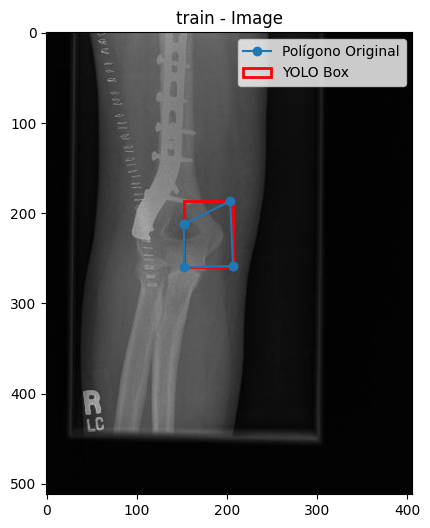

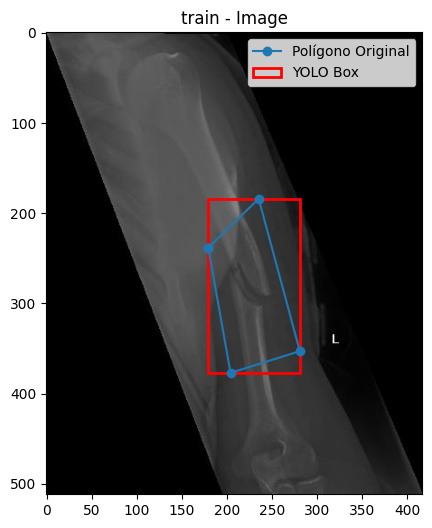

/tmp/ipython-input-3321900603.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


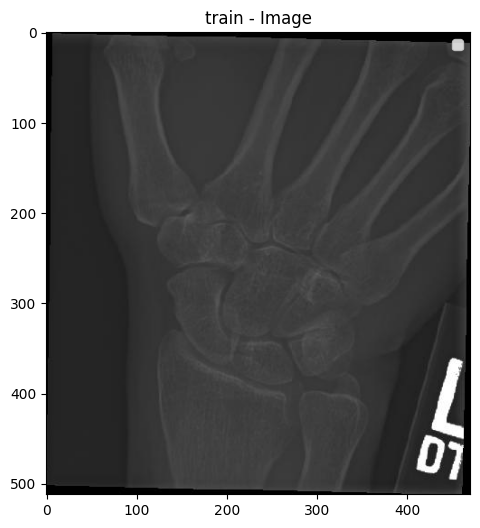

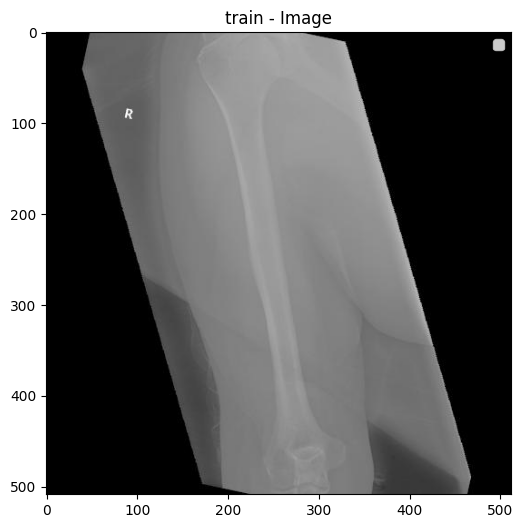

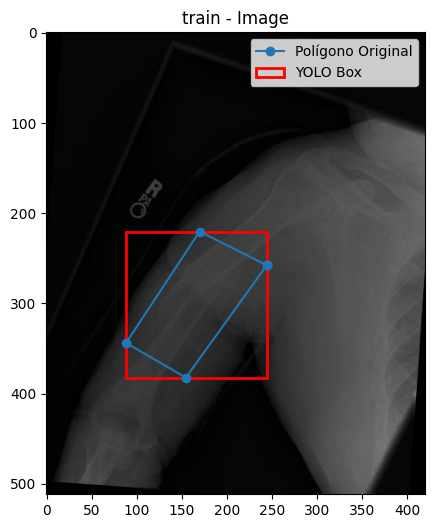

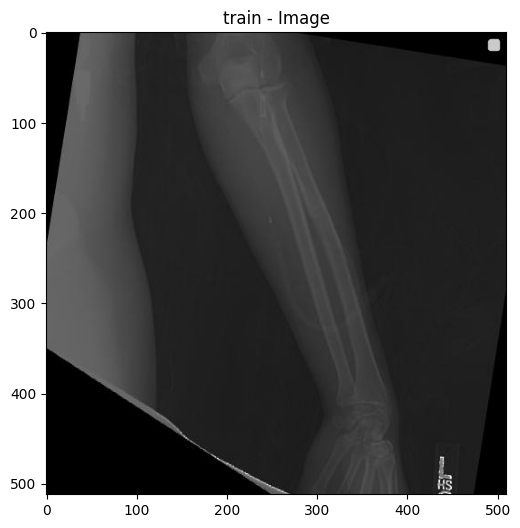

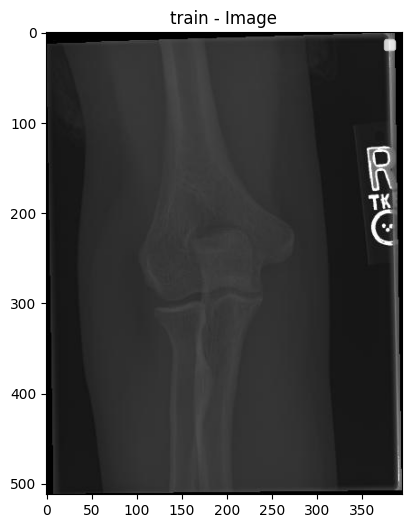

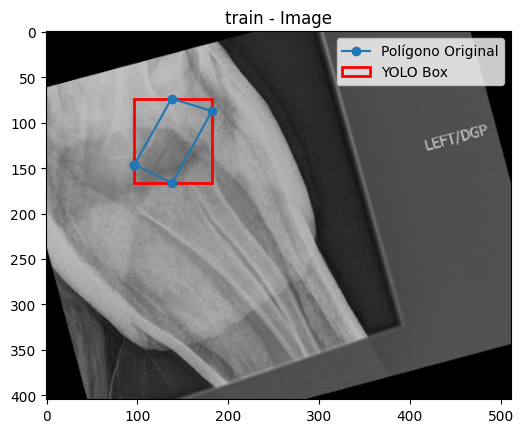

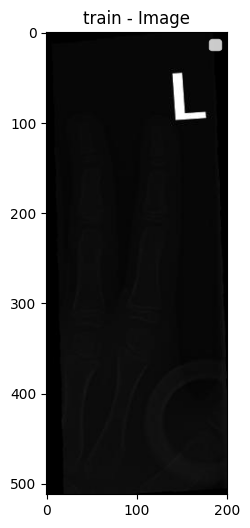

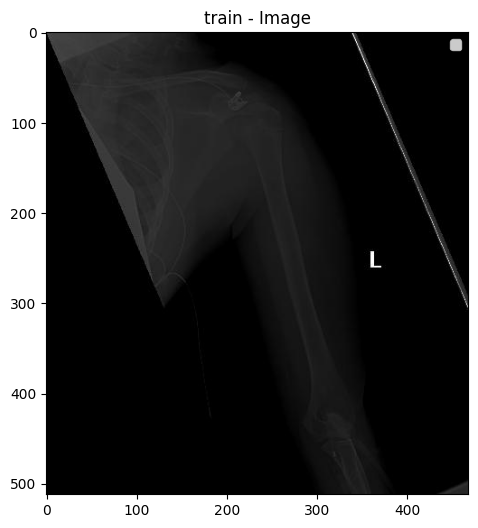

In [ ]:
#Poligono X Yolo
def show_image(split, num_images=3):
    img_dir = os.path.join(base_path, split, "images")
    label_dir = os.path.join(base_path, split, "labels")
    conv_dir = os.path.join(base_path, split, "converted_labels")

    imgs = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))][:num_images]

    for img_name in imgs:
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))
        conv_path = os.path.join(conv_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(6,6))
        plt.imshow(img)

        #Plot do POLÍGONO ORIGINAL
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    data = list(map(float, line.split()))
                    poly = data[1:]
                    xs = poly[0::2]
                    ys = poly[1::2]
                    xs_img = [x * img.shape[1] for x in xs]
                    ys_img = [y * img.shape[0] for y in ys]
                    plt.plot(xs_img + [xs_img[0]], ys_img + [ys_img[0]], '-o', label="Polígono Original")

        #Plot do BOUNDING BOX YOLO
        if os.path.exists(conv_path):
            with open(conv_path, 'r') as f:
                for line in f:
                    cls, cx, cy, w, h = map(float, line.split())
                    xmin = (cx - w/2) * img.shape[1]
                    xmax = (cx + w/2) * img.shape[1]
                    ymin = (cy - h/2) * img.shape[0]
                    ymax = (cy + h/2) * img.shape[0]
                    plt.gca().add_patch(plt.Rectangle(
                        (xmin, ymin), xmax - xmin, ymax - ymin,
                        fill=False, edgecolor='red', linewidth=2, label='YOLO Box'
                    ))

        plt.title(f"{split} - Image")
        plt.legend()
        plt.show()



show_image("train", num_images=10)


📊 RESULTADOS:
- train: 3631 labels, 1827 vazios, 1804 anotados
- valid: 348 labels, 175 vazios, 173 anotados
- test: 169 labels, 86 vazios, 83 anotados


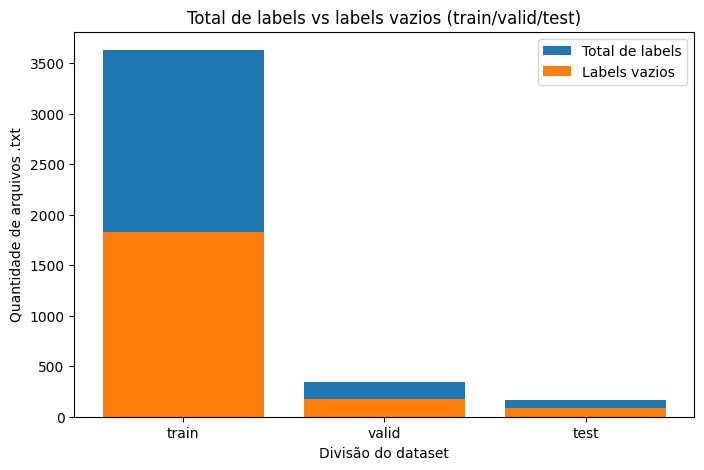

In [ ]:
#Anotados x Vazios(Background)
base_path = "/content/Bone_Fracture_Detect/BoneFractureYolo8"
splits = ["train", "valid", "test"]

total_labels = {}
empty_labels = {}

for split in splits:
    label_dir = os.path.join(base_path, split, "labels")

    if not os.path.exists(label_dir):
        print(f"Pasta não encontrada: {label_dir}")
        total_labels[split] = 0
        empty_labels[split] = 0
        continue

    total = 0
    empty = 0

    for file in os.listdir(label_dir):
        if file.endswith(".txt"):
            total += 1
            if os.path.getsize(os.path.join(label_dir, file)) == 0:
                empty += 1

    total_labels[split] = total
    empty_labels[split] = empty

print("\n📊 RESULTADOS:")
for split in splits:
    print(f"- {split}: {total_labels[split]} labels, {empty_labels[split]} vazios, {total_labels[split] - empty_labels[split]} anotados")

splits_names = list(total_labels.keys())
totals = [total_labels[s] for s in splits_names]
empties = [empty_labels[s] for s in splits_names]

plt.figure(figsize=(8,5))
plt.bar(splits_names, totals, label="Total de labels")
plt.bar(splits_names, empties, label="Labels vazios")
plt.title("Total de labels vs labels vazios (train/valid/test)")
plt.xlabel("Divisão do dataset")
plt.ylabel("Quantidade de arquivos .txt")
plt.legend()
plt.show()



🧹 RESULTADOS DA LIMPEZA:
- train: 1827 labels vazios removidos (de 3631 no total)
- valid: 175 labels vazios removidos (de 348 no total)
- test: 86 labels vazios removidos (de 169 no total)


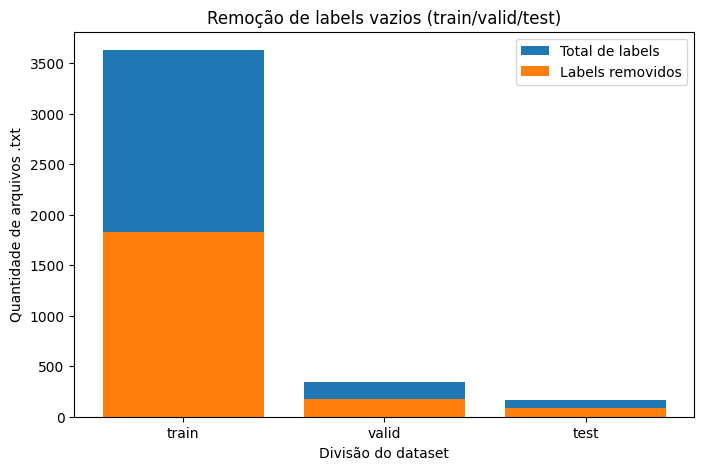

In [ ]:
import os
import matplotlib.pyplot as plt

# Caminho base
base_path = "/content/Bone_Fracture_Detect/BoneFractureYolo8"
splits = ["train", "valid", "test"]

total_labels = {}
deleted_labels = {}

# Extensões possíveis de imagem
image_exts = [".jpg", ".jpeg", ".png"]

for split in splits:
    label_dir = os.path.join(base_path, split, "labels")
    image_dir = os.path.join(base_path, split, "images")

    if not os.path.exists(label_dir):
        print(f"Pasta não encontrada: {label_dir}")
        total_labels[split] = 0
        deleted_labels[split] = 0
        continue

    total = 0
    deleted = 0

    for file in os.listdir(label_dir):
        if file.endswith(".txt"):
            total += 1
            label_path = os.path.join(label_dir, file)

            # Verifica se o label está vazio
            if os.path.getsize(label_path) == 0:
                deleted += 1
                os.remove(label_path)  # Apaga o label vazio

                # Apaga imagem correspondente (caso exista)
                base_name = os.path.splitext(file)[0]
                for ext in image_exts:
                    img_path = os.path.join(image_dir, base_name + ext)
                    if os.path.exists(img_path):
                        os.remove(img_path)
                        break  # já apagou, sai do loop

    total_labels[split] = total
    deleted_labels[split] = deleted

print("\n🧹 RESULTADOS DA LIMPEZA:")
for split in splits:
    print(f"- {split}: {deleted_labels[split]} labels vazios removidos (de {total_labels[split]} no total)")

# Gráfico (opcional)
splits_names = list(total_labels.keys())
totals = [total_labels[s] for s in splits_names]
empties = [deleted_labels[s] for s in splits_names]

plt.figure(figsize=(8,5))
plt.bar(splits_names, totals, label="Total de labels")
plt.bar(splits_names, empties, label="Labels removidos")
plt.title("Remoção de labels vazios (train/valid/test)")
plt.xlabel("Divisão do dataset")
plt.ylabel("Quantidade de arquivos .txt")
plt.legend()
plt.show()



📊 RESULTADOS:
- Classe 1: 531 anotações
- Classe 2: 316 anotações
- Classe 3: 3 anotações
- Classe 4: 311 anotações
- Classe 5: 360 anotações
- Classe 6: 228 anotações
- Total: 1749 anotações


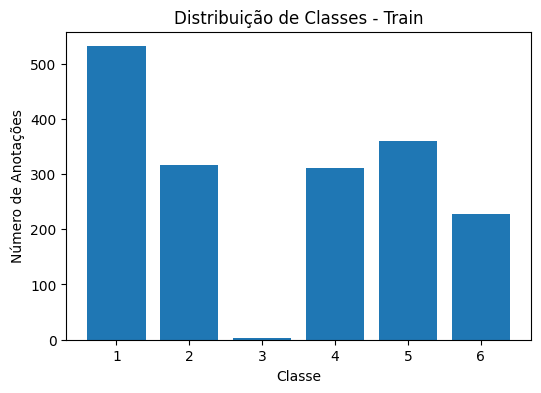


📊 RESULTADOS:
- Classe 1: 48 anotações
- Classe 2: 43 anotações
- Classe 3: 0 anotações
- Classe 4: 36 anotações
- Classe 5: 20 anotações
- Classe 6: 28 anotações
- Total: 175 anotações


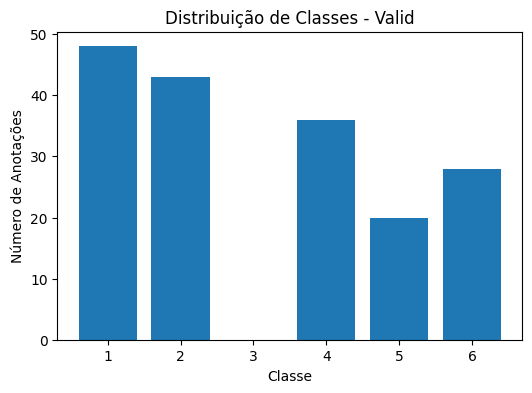


📊 RESULTADOS:
- Classe 1: 27 anotações
- Classe 2: 14 anotações
- Classe 3: 0 anotações
- Classe 4: 15 anotações
- Classe 5: 17 anotações
- Classe 6: 6 anotações
- Total: 79 anotações


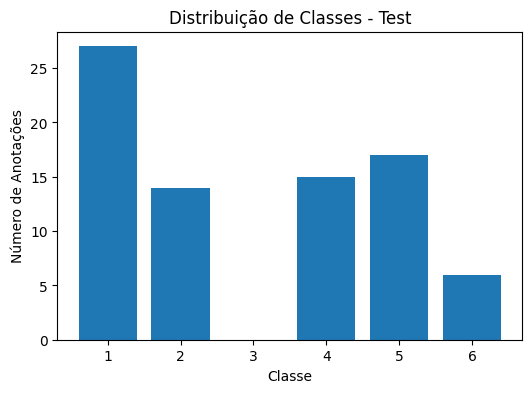

In [ ]:
#Distribuição de Classes (TRAIN, VALID, TEST)
base_path = "/content/Bone_Fracture_Detect/BoneFractureYolo8"
splits = ["train", "valid", "test"]

def count_classes(label_folder):
    """Conta quantas anotações de cada classe existem."""
    class_counts = {}
    for label_file in os.listdir(label_folder):
        if label_file.endswith(".txt"):
            filepath = os.path.join(label_folder, label_file)
            if os.path.getsize(filepath) > 0:
                with open(filepath, 'r') as f:
                    for line in f:
                        cls = line.split()[0]
                        class_counts[cls] = class_counts.get(cls, 0) + 1
    return class_counts

for split in splits:
    label_dir = os.path.join(base_path, split, "labels")

    if not os.path.exists(label_dir):
        print(f"Pasta não encontrada: {label_dir}")
        continue
    class_counts = count_classes(label_dir)

    if not class_counts:
        print(f"Nenhuma anotação encontrada em {split}")
        continue

    classes = [str(i) for i in range(1, 7)]
    counts = [class_counts.get(cls, 0) for cls in classes]

    sum = 0
    print("\n📊 RESULTADOS:")
    for i in range(len(classes)):
        print(f"- Classe {classes[i]}: {counts[i]} anotações")
        sum += counts[i]
    print(f"- Total: {sum} anotações")


    # 📊 Plot
    plt.figure(figsize=(6,4))
    plt.bar(classes, counts)
    plt.title(f"Distribuição de Classes - {split.capitalize()}")
    plt.xlabel("Classe")
    plt.ylabel("Número de Anotações")
    plt.show()


In [ ]:
def show_image_sample(dataset_split, img_name, base_path="/content/Bone_Fracture_Detect/BoneFractureYolo8"):
    img_path = os.path.join(base_path, dataset_split, "images", img_name)
    label_path = os.path.join(base_path, dataset_split, "converted_labels", img_name.replace(".jpg", ".txt"))

    if not os.path.exists(img_path) or not os.path.exists(label_path):
        print(f"Arquivo não encontrado: {img_name}")
        return
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    with open(label_path, "r") as file:
        lines = file.readlines()

    for line in lines:
        cls, x_center, y_center, bw, bh = map(float, line.split())
        x1 = int((x_center - bw / 2) * w)
        y1 = int((y_center - bh / 2) * h)
        x2 = int((x_center + bw / 2) * w)
        y2 = int((y_center + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()


In [ ]:
def show_example_each_class(base_path, dataset_split="train", max_classes=6):
    label_dir = os.path.join(base_path, dataset_split, "converted_labels")
    image_dir = os.path.join(base_path, dataset_split, "images")

    class_to_images = {i: [] for i in range(max_classes)}

    for label_file in os.listdir(label_dir):
        if label_file.endswith(".txt"):
            label_path = os.path.join(label_dir, label_file)
            with open(label_path, "r") as f:
                labels = f.readlines()

            for label in labels:
                class_id = int(label.split()[0])
                if class_id < max_classes:
                    img_name = label_file.replace(".txt", ".jpg")
                    img_path = os.path.join(image_dir, img_name)
                    class_to_images[class_id].append(img_path)

    for class_id in sorted(class_to_images.keys()):
        if len(class_to_images[class_id]) == 0:
            print(f"Nenhuma imagem encontrada para a classe {class_id}")
            continue

        img_path = class_to_images[class_id][0]
        print(f"Classe {class_id}")
        show_image_sample(dataset_split, os.path.basename(img_path), base_path)

Classe 0


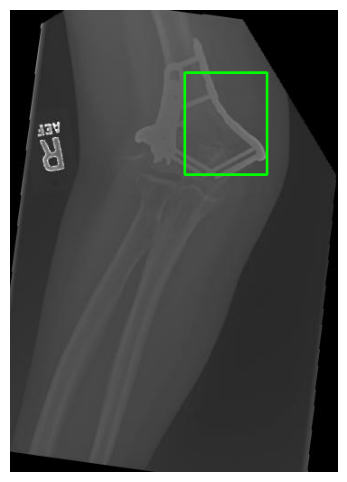

Classe 1


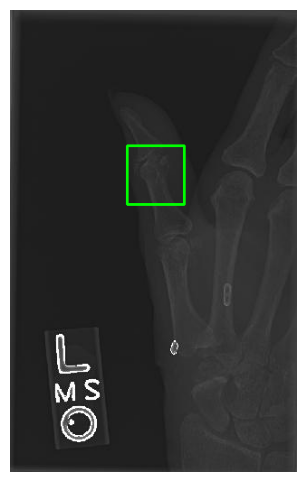

Classe 2


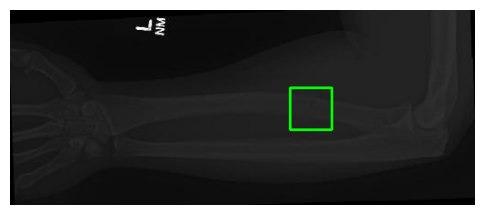

Classe 3


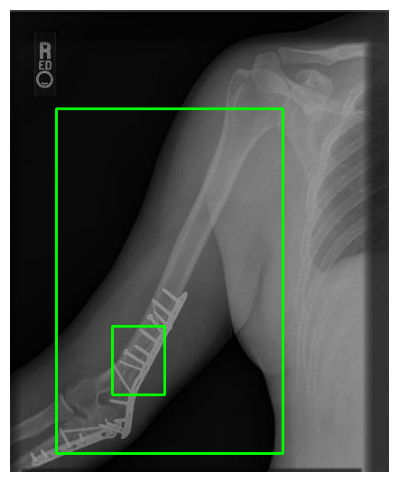

Classe 4


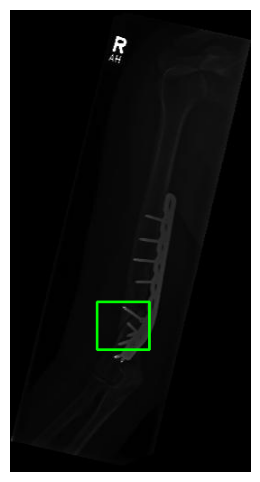

Classe 5


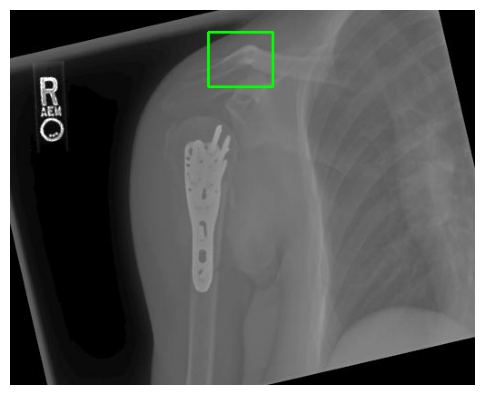

In [ ]:
base_path = "/content/Bone_Fracture_Detect/BoneFractureYolo8"
show_example_each_class(base_path, dataset_split="train", max_classes=6)

In [ ]:
#Remover Classe 3 (Apenas 3 exemplos no conjunto de treino)
base_path = "/content/Bone_Fracture_Detect/BoneFractureYolo8"
splits = ["train", "valid", "test"]
classe_remover = "3"

def remover_classe(label_dir, img_dir, classe_alvo):
    removidos = 0
    for label_file in os.listdir(label_dir):
        if not label_file.endswith(".txt"):
            continue

        label_path = os.path.join(label_dir, label_file)
        with open(label_path, 'r') as f:
            linhas = f.readlines()

        contem_classe = any(line.startswith(classe_alvo + " ") for line in linhas)

        if contem_classe:
            os.remove(label_path)
            nome_base = os.path.splitext(label_file)[0]
            for ext in [".jpg", ".png", ".jpeg"]:
                img_path = os.path.join(img_dir, nome_base + ext)
                if os.path.exists(img_path):
                    os.remove(img_path)
                    break
            removidos += 1

    return removidos


for split in splits:
    label_dir = os.path.join(base_path, split, "labels")
    img_dir = os.path.join(base_path, split, "images")

    if not os.path.exists(label_dir):
        print(f"Pasta não encontrada: {label_dir}")
        continue

    removidos = remover_classe(label_dir, img_dir, classe_remover)
    print(f"{removidos} arquivos (imagem + label) contendo a classe {classe_remover} removidos de {split}/")


3 arquivos (imagem + label) contendo a classe 3 removidos de train/
0 arquivos (imagem + label) contendo a classe 3 removidos de valid/
0 arquivos (imagem + label) contendo a classe 3 removidos de test/


In [ ]:
#Remover a classe 3 do arquivo yaml
yaml_path = "/content/Bone_Fracture_Detect/BoneFractureYolo8/data.yaml"

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

print("Classes originais:", data["names"])
class_to_remove = 3
if 0 <= class_to_remove < len(data["names"]):
    removed_class = data["names"].pop(class_to_remove)
    data["nc"] = len(data["names"])

    with open(yaml_path, 'w') as f:
        yaml.dump(data, f, sort_keys=False)

    print(f"Classe removida: '{removed_class}'")
else:
    print("Índice de classe inválido!")


Classes originais: ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive']
Classe removida: 'humerus fracture'


In [ ]:
#Remover pasta de labels de poligonos
base_path = "/content/Bone_Fracture_Detect/BoneFractureYolo8"
splits = ["train", "valid", "test"]

for split in splits:
    old_labels = os.path.join(base_path, split, "labels")
    new_labels = os.path.join(base_path, split, "converted_labels")
    if os.path.exists(old_labels):
        shutil.rmtree(old_labels)
        print(f"Removido: {old_labels}")
    if os.path.exists(new_labels):
        os.rename(new_labels, old_labels)
        print(f"Renomeado: {new_labels} → {old_labels}")
    else:
        print(f"Aviso: {new_labels} não encontrado!")


Removido: /content/Bone_Fracture_Detect/BoneFractureYolo8/train/labels
Renomeado: /content/Bone_Fracture_Detect/BoneFractureYolo8/train/converted_labels → /content/Bone_Fracture_Detect/BoneFractureYolo8/train/labels
Removido: /content/Bone_Fracture_Detect/BoneFractureYolo8/valid/labels
Renomeado: /content/Bone_Fracture_Detect/BoneFractureYolo8/valid/converted_labels → /content/Bone_Fracture_Detect/BoneFractureYolo8/valid/labels
Removido: /content/Bone_Fracture_Detect/BoneFractureYolo8/test/labels
Renomeado: /content/Bone_Fracture_Detect/BoneFractureYolo8/test/converted_labels → /content/Bone_Fracture_Detect/BoneFractureYolo8/test/labels


In [ ]:
splits = ["train", "valid", "test"]


classe_removida_index = 3
def remapear_labels(label_dir, index_removido):
    arquivos_processados = 0
    for label_file in os.listdir(label_dir):
        if not label_file.endswith(".txt"):
            continue

        label_path = os.path.join(label_dir, label_file)
        linhas_corrigidas = []

        try:
            with open(label_path, 'r') as f:
                linhas = f.readlines()

            for linha in linhas:
                parts = linha.strip().split()
                if not parts:
                    continue # Linha vazia

                class_index = int(parts[0])

                # A lógica principal:
                # Se o índice atual for MAIOR que o índice que removemos,
                # subtraímos 1 dele.
                if class_index > index_removido:
                    class_index -= 1

                parts[0] = str(class_index)
                linhas_corrigidas.append(" ".join(parts))

            with open(label_path, 'w') as f:
                f.write("\n".join(linhas_corrigidas))

            arquivos_processados += 1

        except Exception as e:
            print(f"ERRO ao processar o arquivo {label_path}: {e}")

    return arquivos_processados

for split in splits:
    label_dir = os.path.join(base_path, split, "labels")

    if not os.path.exists(label_dir):
        print(f"Pasta não encontrada, pulando: {label_dir}")
        continue

    removidos = remapear_labels(label_dir, classe_removida_index)
    print(f"{removidos} arquivos de label remapeados em {split}/")


3631 arquivos de label remapeados em train/
348 arquivos de label remapeados em valid/
169 arquivos de label remapeados em test/


#Criação do Modelo

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando dispositivo:", device)

Usando dispositivo: cpu


In [ ]:
model = YOLO('yolo11n.pt')
data_yaml_path = "/content/Bone_Fracture_Detect/BoneFractureYolo8/data.yaml"

results = model.train(
        data=data_yaml_path,
        epochs=100,
        batch=16,
        imgsz=640,
        patience=15,
        save=True,
        save_period=-1,
        project="bone_yolo",
        name="exp",
        device=device
    )


Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Bone_Fracture_Detect/BoneFractureYolo8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspective

In [ ]:
# #Código executado localmente em uma máquina com placa de vídeo dedicada
# results = model.train(
#         data=yaml_path,
#         epochs=100,
#         batch=16,
#         imgsz=640,
#         patience=15,

#         lr0=0.005,
#         lrf=0.01,
#         optimizer="auto",
#         weight_decay=0.0005,

#         mosaic=0.0,
#         mixup=0.0,
#         hsv_h=0.015,
#         hsv_s=0.7,
#         hsv_v=0.4,
#         erasing=0.0,

#         fliplr=0.5,
#         degrees=5.0,
#         translate=0.1,
#         scale=0.5,

#         plots=True,
#         verbose=True,
#         save=True,
#         save_period=-1,
#         project="bone_yolo",
#         name="exp",
#         device=device
#     )

In [ ]:
#Código executado localmente em uma máquina com placa de vídeo dedicada (Executado com e sem imagens de apenas background)
# model = YOLO('yolo11n.pt')  # escolha o modelo base
# yaml_path = "bonefractureyolo/data.yaml"
# results = model.train(
#         data=yaml_path,
#         epochs=150,
#         batch=16,
#         imgsz=640,
#         patience=50,


#         lr0=0.01,
#         lrf=0.01,
#         optimizer="auto",
#         weight_decay=0.0005,


#         mosaic=0.0,
#         mixup=0.0,
#         hsv_h=0.0,
#         hsv_s=0.0,
#         fliplr=0.5,


#         hsv_v=0.4,
#         degrees=15.0,
#         translate=0.1,
#         scale=0.1,


#         plots=True,
#         verbose=True,
#         save=True,
#         resume=True,
#         project="bone_yolo",
#         name="exp_safe_params",
#         device=device
#     )


#Testes

In [ ]:
model = YOLO("/content/default_aug.pt")
metrics = model.val(data="/content/Bone_Fracture_Detect/BoneFractureYolo8/data.yaml", split="test")

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 100 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 327.2±138.6 MB/s, size: 10.5 KB)
val: Scanning /content/Bone_Fracture_Detect/BoneFractureYolo8/test/labels.cache... 169 images, 86 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 306.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 0.3it/s 41.9s
                   all        169         96      0.246      0.168      0.139     0.0513
        elbow positive         13         17       0.29      0.235      0.159     0.0419
      fingers positive         22         27      0.334      0.222       0.13     0.0244
      forearm fracture         13         14      0.775      0.494      0.523      0.235
               humerus         14         15          0          0          0          0
     should

In [ ]:
model2 = YOLO("/content/augmentation1.pt")
metrics = model2.val(data="/content/Bone_Fracture_Detect/BoneFractureYolo8/data.yaml", split="test")

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 100 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 474.9±100.3 MB/s, size: 10.4 KB)
val: Scanning /content/Bone_Fracture_Detect/BoneFractureYolo8/test/labels.cache... 169 images, 86 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 254.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 0.3it/s 36.9s
                   all        169         96      0.159      0.146     0.0941     0.0282
        elbow positive         13         17      0.107      0.044     0.0335    0.00729
      fingers positive         22         27      0.213      0.185      0.116     0.0347
      forearm fracture         13         14      0.315      0.286      0.238     0.0651
               humerus         14         15      0.186      0.133     0.0683     0.0225
     should

In [ ]:
model3 = YOLO("/content/augmentation2.pt")
metrics = model3.val(data="/content/Bone_Fracture_Detect/BoneFractureYolo8/data.yaml", split="test")

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 100 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 373.7±143.6 MB/s, size: 9.5 KB)
val: Scanning /content/Bone_Fracture_Detect/BoneFractureYolo8/test/labels.cache... 169 images, 86 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 237.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 0.3it/s 36.4s
                   all        169         96      0.352      0.229      0.219      0.091
        elbow positive         13         17          0          0     0.0268     0.0161
      fingers positive         22         27      0.288      0.148      0.175     0.0411
      forearm fracture         13         14      0.822      0.333      0.438      0.222
               humerus         14         15      0.451      0.385      0.306      0.139
     shoulde

In [ ]:
model4 = YOLO("/content/best.pt")
metrics = model4.val(data="/content/Bone_Fracture_Detect/BoneFractureYolo8/data.yaml", split="test")

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 100 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 87.3±24.9 MB/s, size: 8.7 KB)
val: Scanning /content/Bone_Fracture_Detect/BoneFractureYolo8/test/labels... 83 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 83/83 1.3Kit/s 0.1s
val: New cache created: /content/Bone_Fracture_Detect/BoneFractureYolo8/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 0.3it/s 22.0s
                   all         83         96      0.333       0.23       0.24     0.0925
        elbow positive         13         17     0.0606     0.0285     0.0284    0.00569
      fingers positive         22         27      0.397      0.222       0.17     0.0426
      forearm fracture         13         14      0.553      0.286      0.392      0.207
               humerus     

In [ ]:
def visualizar_predicoes(model, data_yaml_path, num_imagens=5, conf=0.25):
    with open(data_yaml_path, "r") as f:
        data = yaml.safe_load(f)

    base_dir = "/content/Bone_Fracture_Detect/BoneFractureYolo8"
    test_dir = os.path.join(base_dir, "test")
    images_dir = os.path.join(test_dir, "images")
    labels_dir = os.path.join(test_dir, "labels")
    image_files = [f for f in os.listdir(images_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
    random.shuffle(image_files)
    imagens_plotadas = 0


    for img_name in image_files:
        if imagens_plotadas >= num_imagens:
            break

        img_path = os.path.join(images_dir, img_name)
        label_path = os.path.join(labels_dir, os.path.splitext(img_name)[0] + ".txt")

        if not os.path.exists(label_path):
            continue

        with open(label_path, "r") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]

        if len(lines) == 0:
            continue

        img = cv2.imread(img_path)
        if img is None:
            print(f"Erro ao carregar {img_name}, pulando...")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        results = model(img, conf=conf, verbose=False)[0]

        img_label = img.copy()
        img_pred = img.copy()

        for line in lines:
            parts = line.split()
            if len(parts) != 5:
                continue
            cls, x, y, bw, bh = map(float, parts)
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)
            cv2.rectangle(img_label, (x1, y1), (x2, y2), (0, 255, 0), 2)
            class_name = data["names"][int(cls)] if "names" in data else str(int(cls))
            cv2.putText(img_label, class_name, (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        for box in results.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf_score = float(box.conf[0])
            cls_id = int(box.cls[0])
            class_name = data["names"][cls_id] if "names" in data else str(cls_id)
            cv2.rectangle(img_pred, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(img_pred, f"{class_name} {conf_score:.2f}",
                        (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

        fig, axs = plt.subplots(1, 2, figsize=(12, 6))
        axs[0].imshow(img_label)
        axs[0].set_title("Label")
        axs[0].axis("off")

        axs[1].imshow(img_pred)
        axs[1].set_title("Predição (YOLO)")
        axs[1].axis("off")

        plt.suptitle("COMPARAÇÂO:")
        plt.tight_layout()
        plt.show()

        imagens_plotadas += 1

    if imagens_plotadas == 0:
        print("Nenhuma imagem com anotações encontrada no conjunto de teste.")


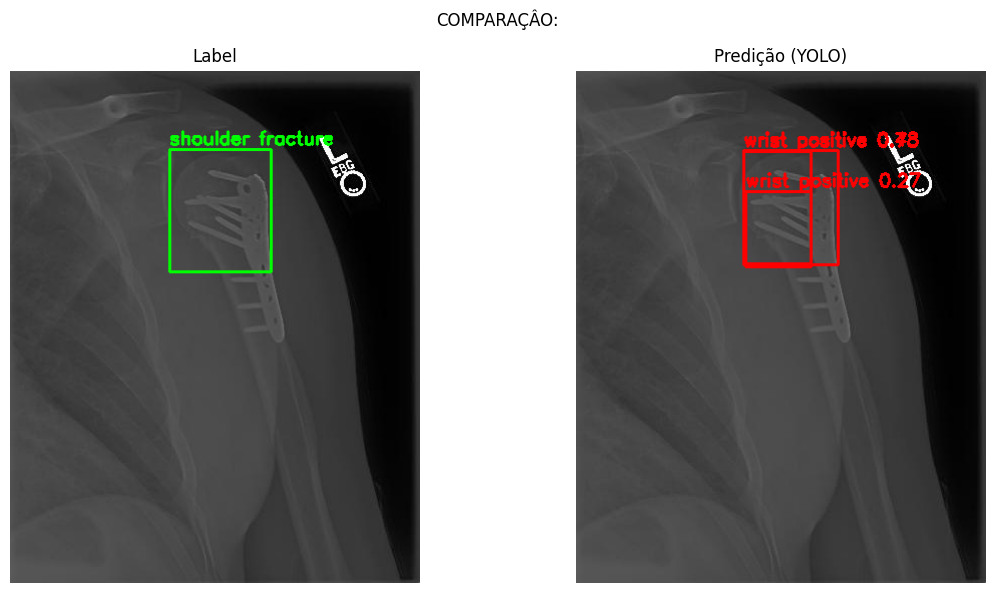

In [ ]:
data_yaml = "/content/Bone_Fracture_Detect/BoneFractureYolo8/data.yaml"
visualizar_predicoes(model, data_yaml, num_imagens=1)

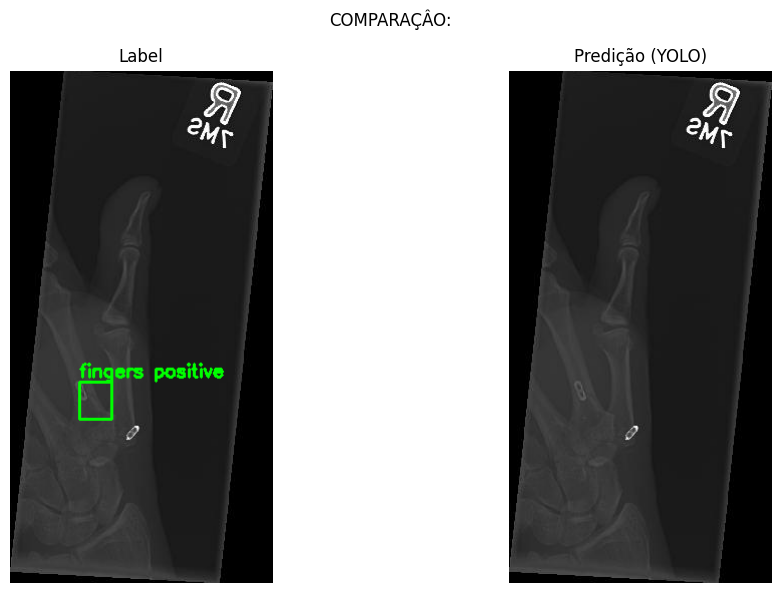

In [ ]:
data_yaml = "/content/Bone_Fracture_Detect/BoneFractureYolo8/data.yaml"
visualizar_predicoes(model2, data_yaml, num_imagens=1)

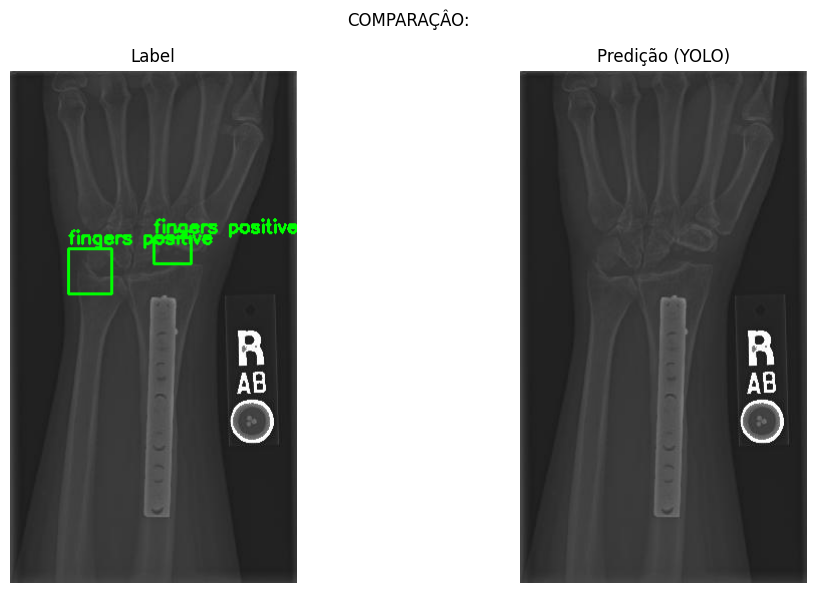

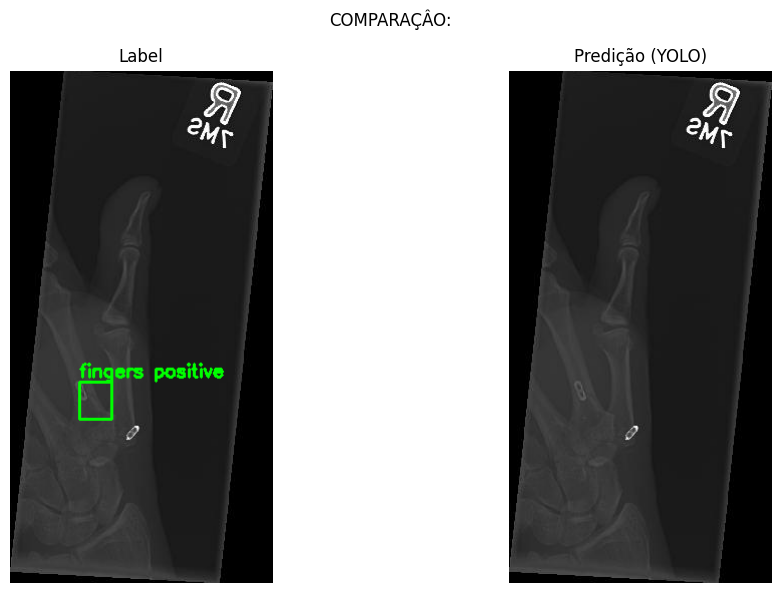

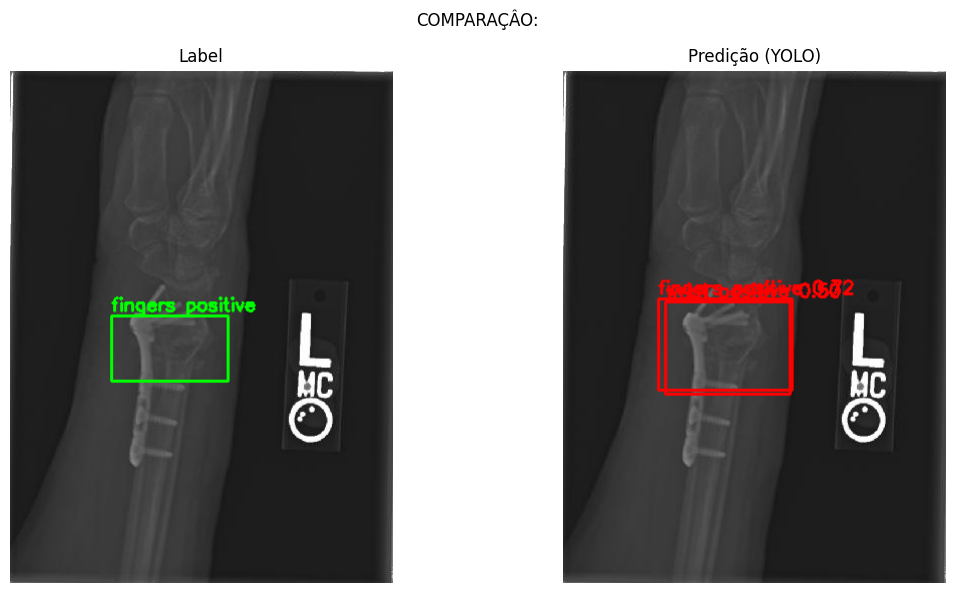

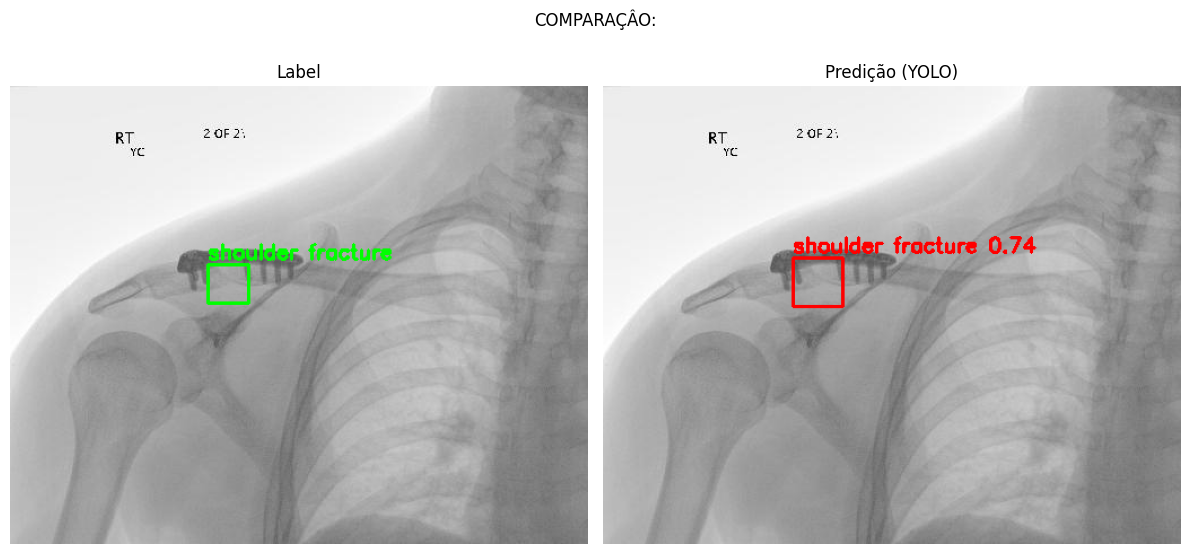

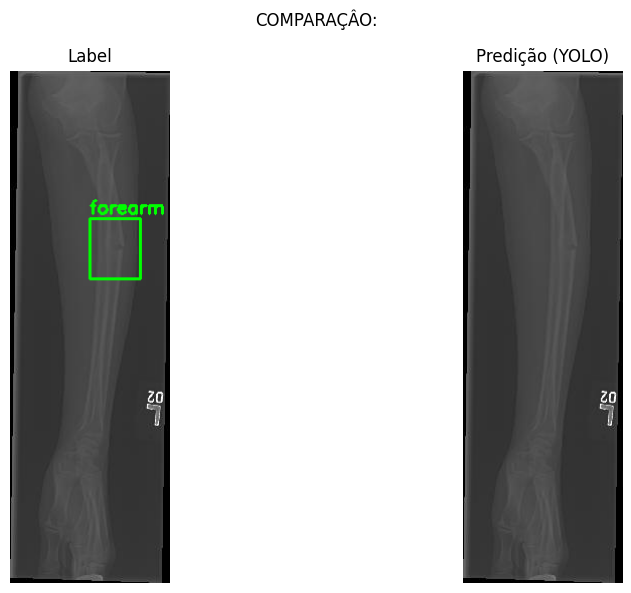

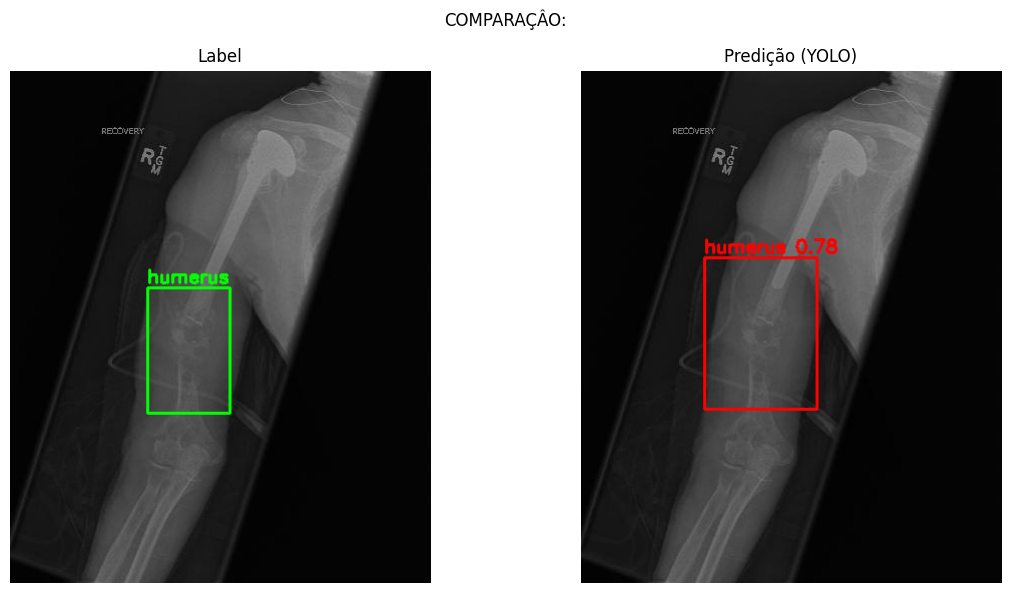

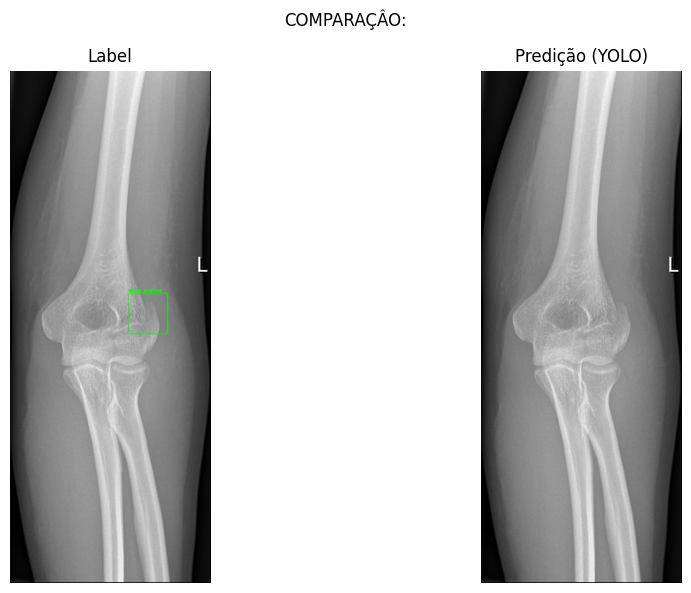

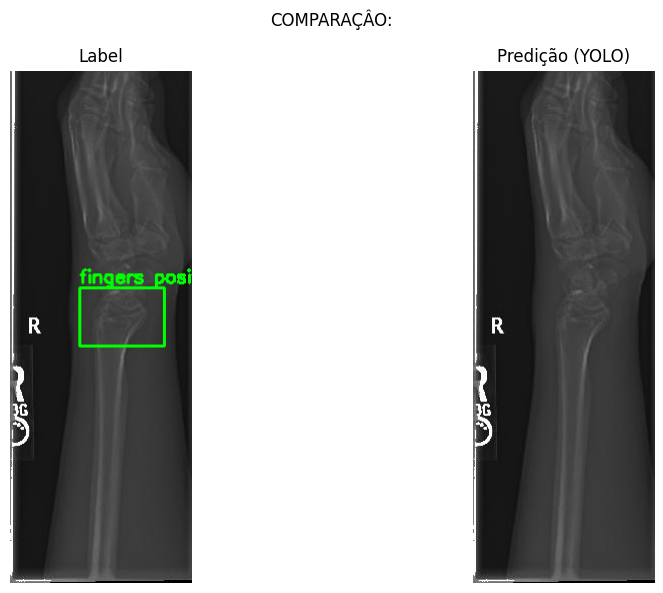

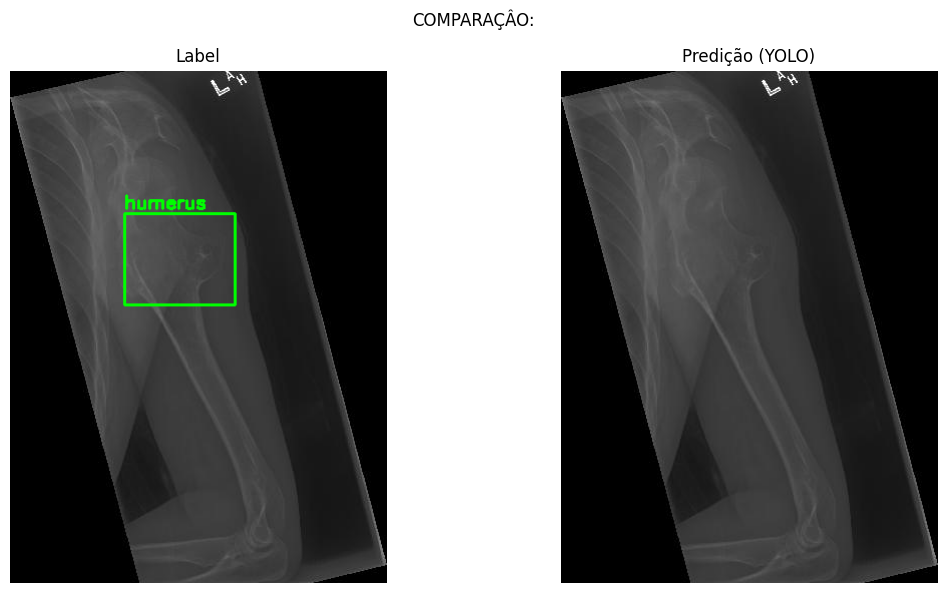

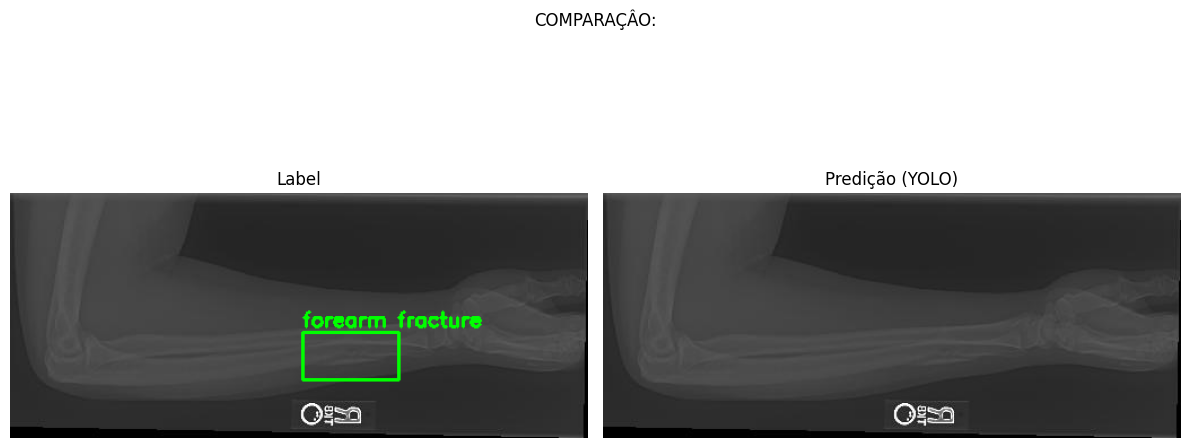

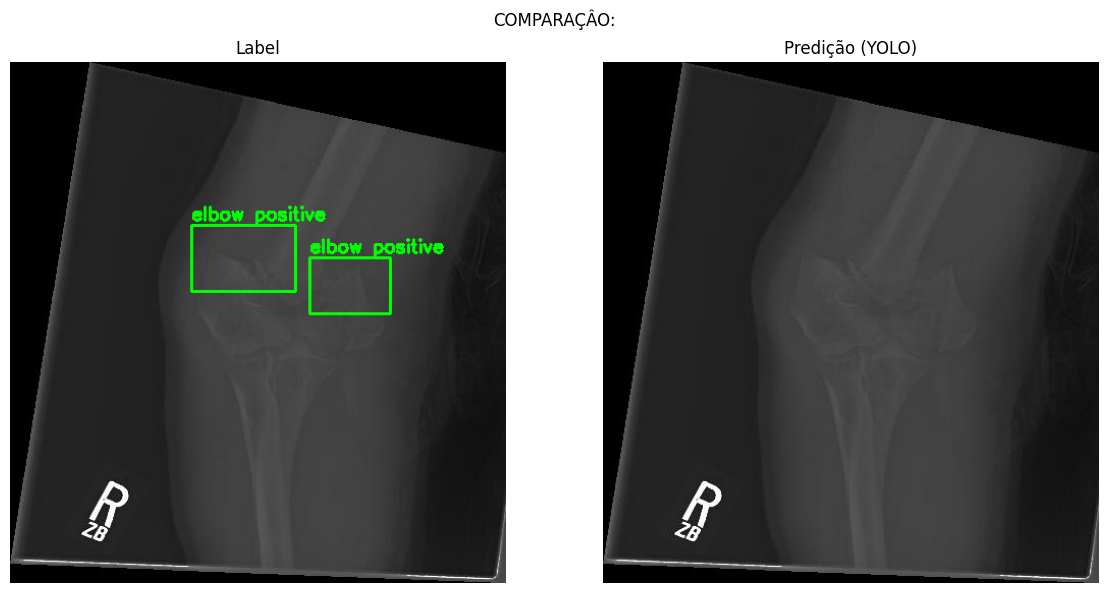

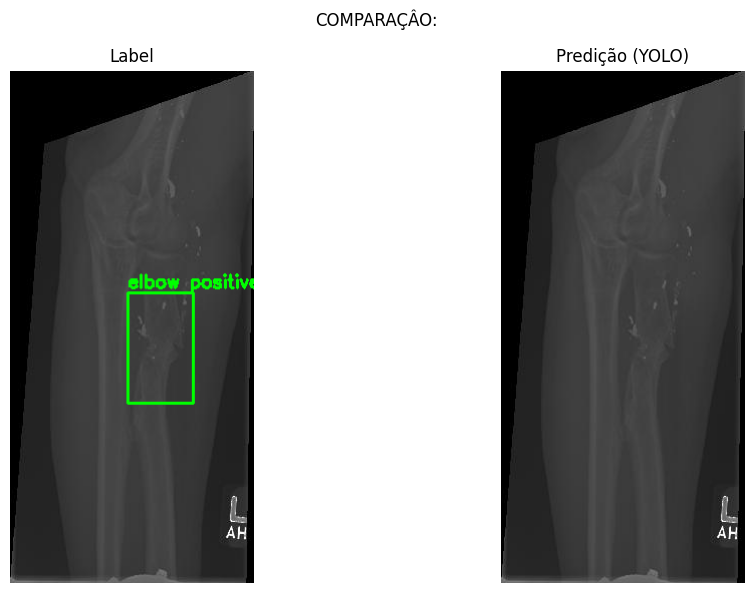

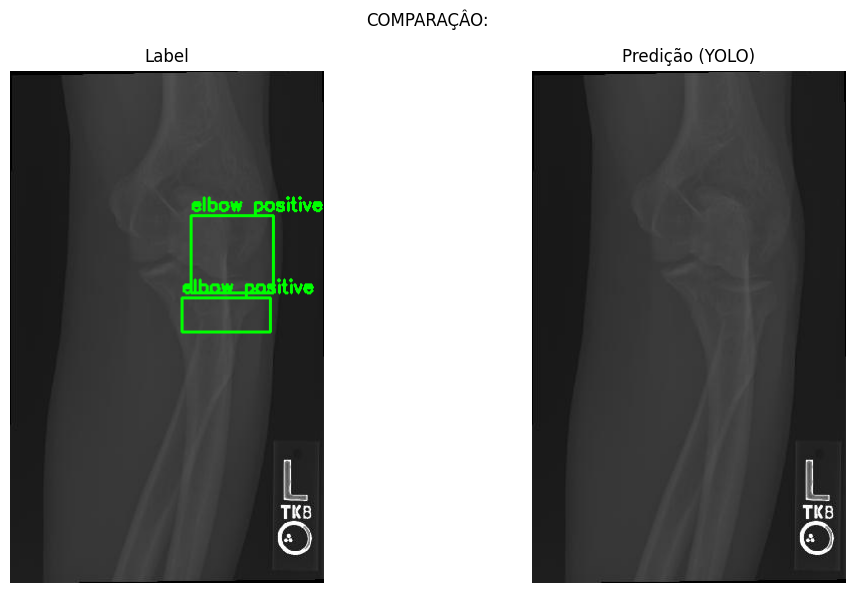

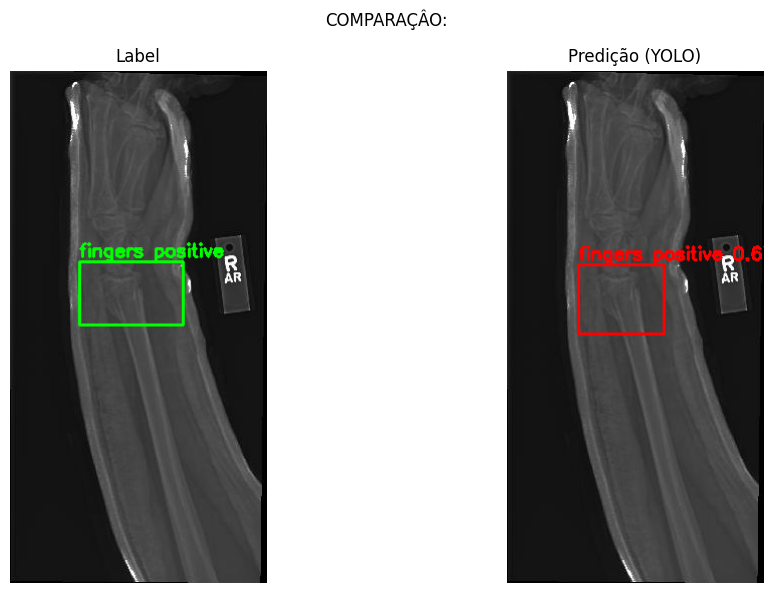

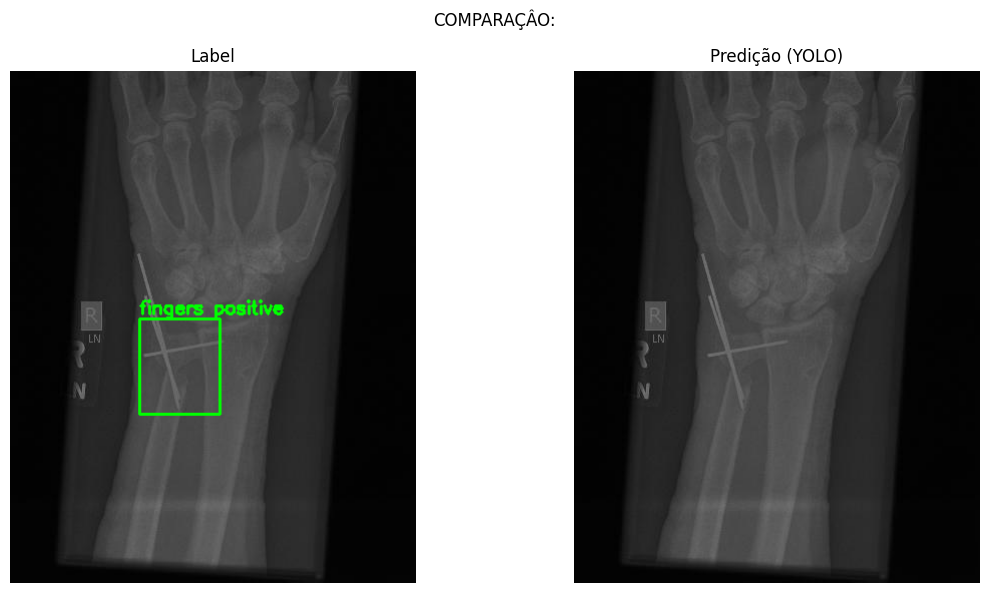

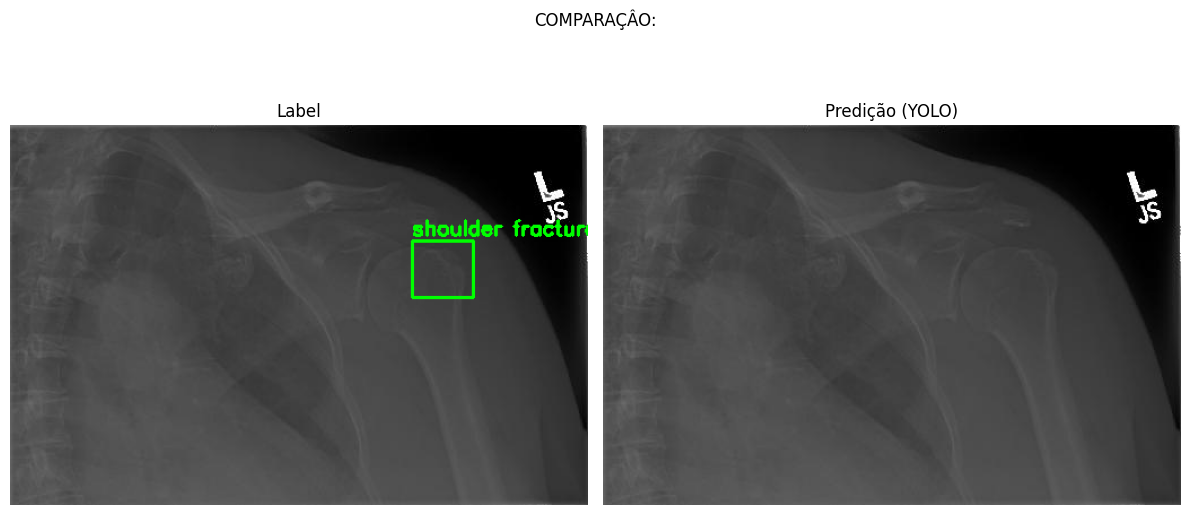

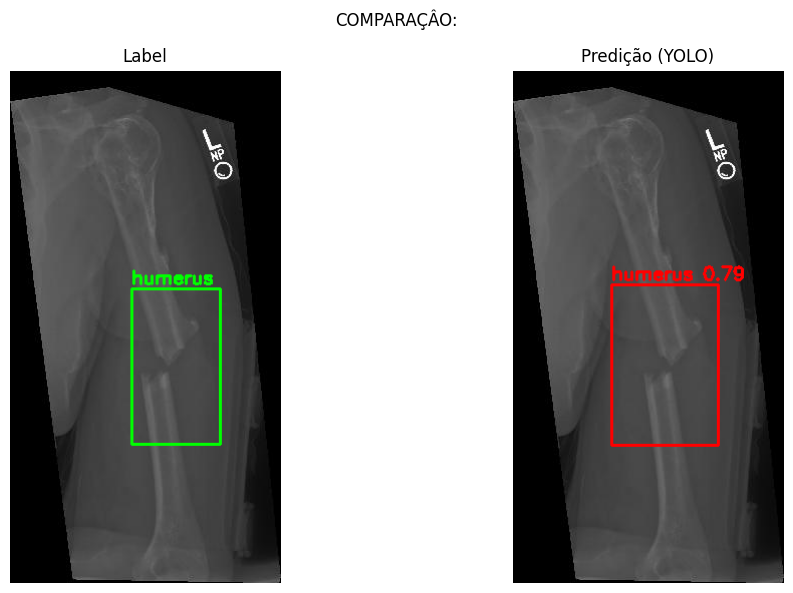

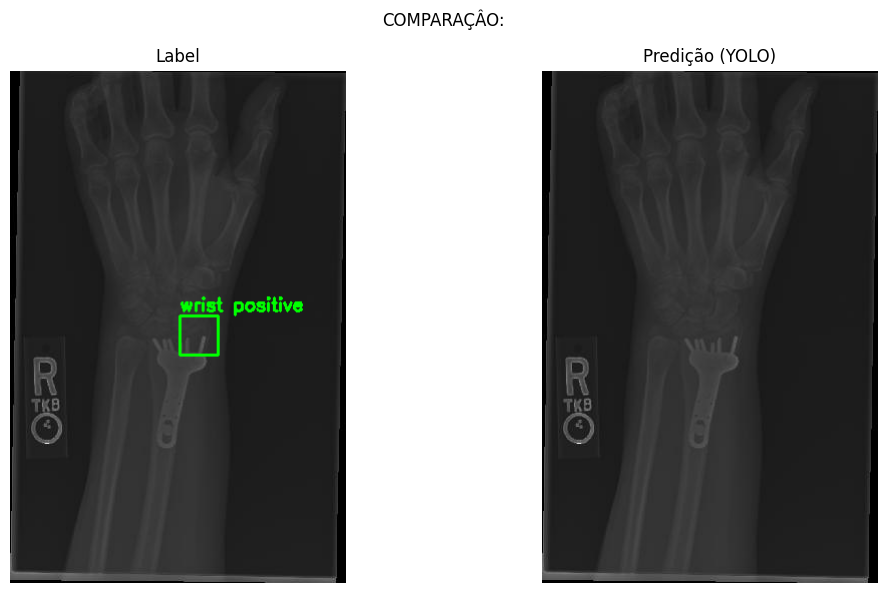

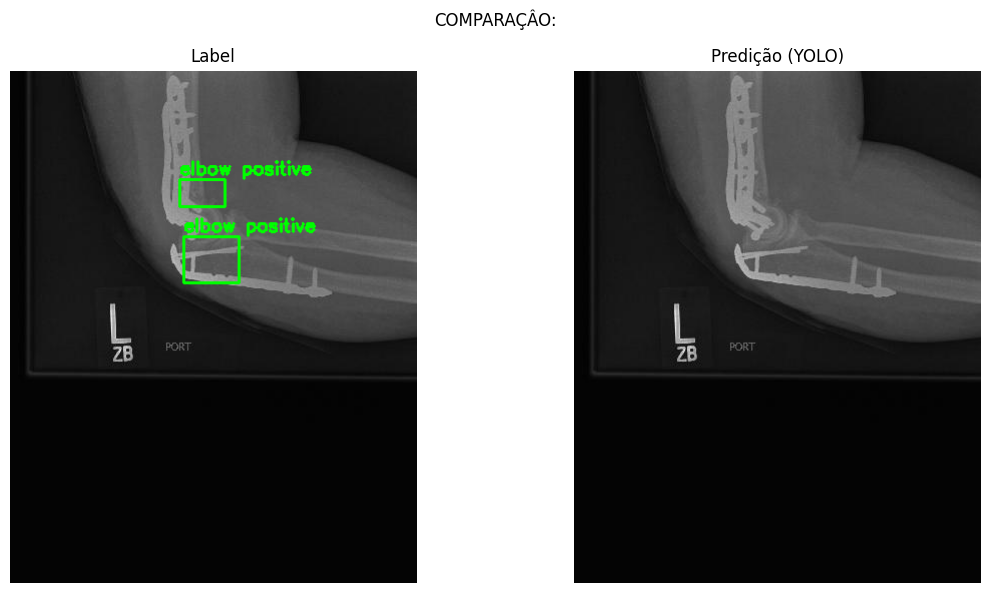

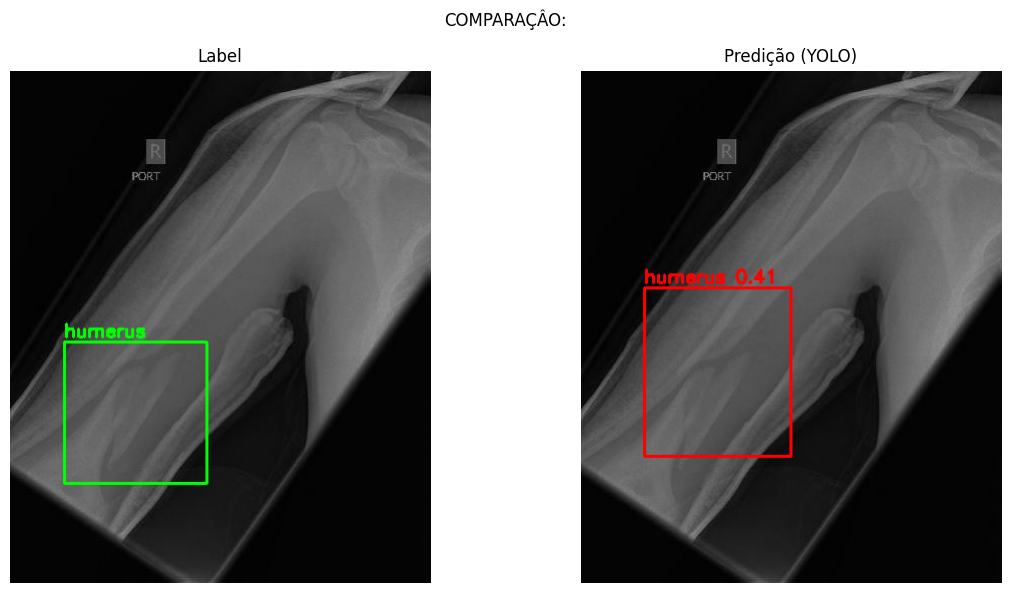

In [ ]:
#Melhor modelo
data_yaml = "/content/Bone_Fracture_Detect/BoneFractureYolo8/data.yaml"
visualizar_predicoes(model3, data_yaml, num_imagens=20, conf=0.25)

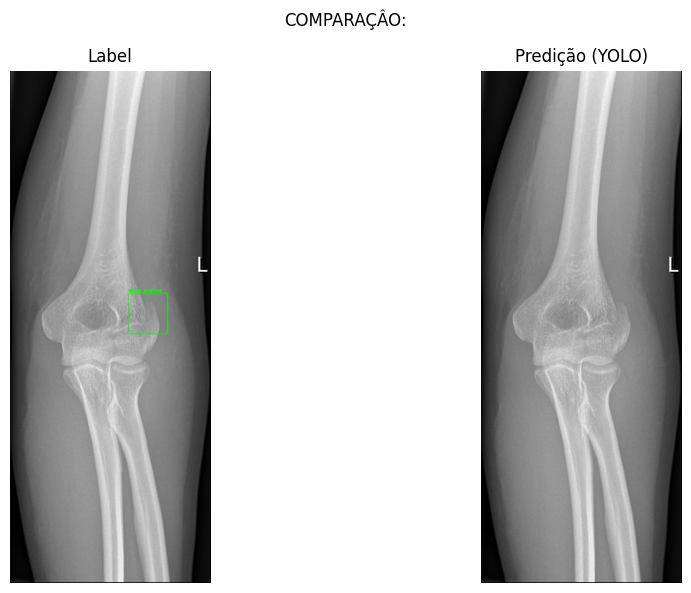

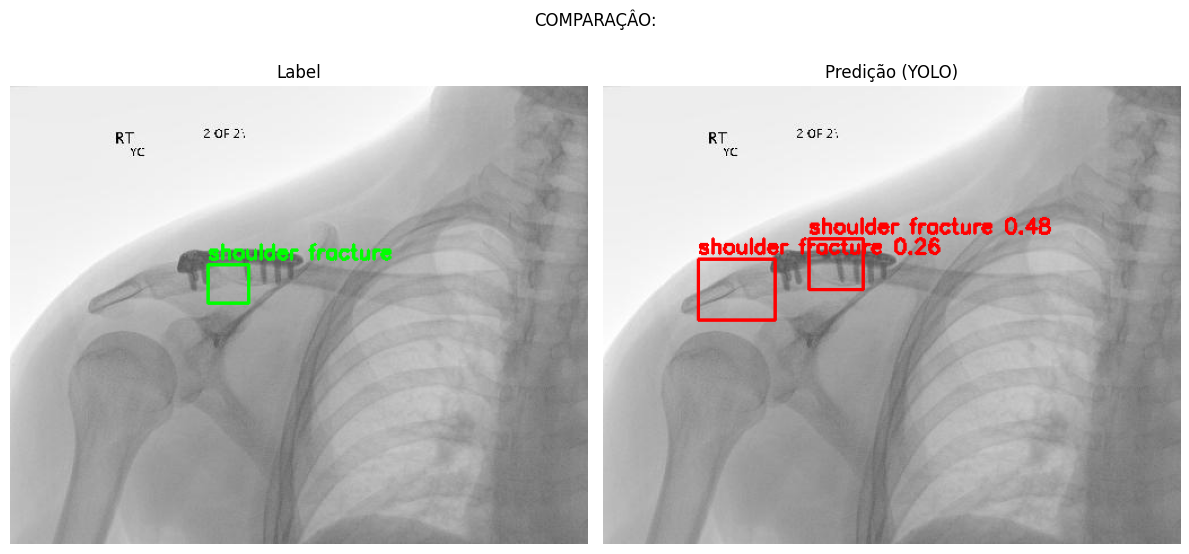

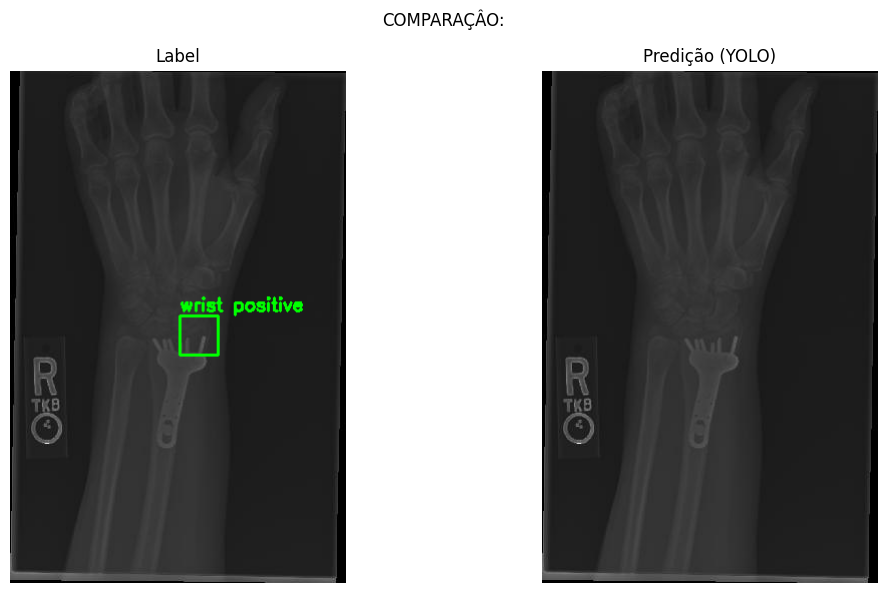

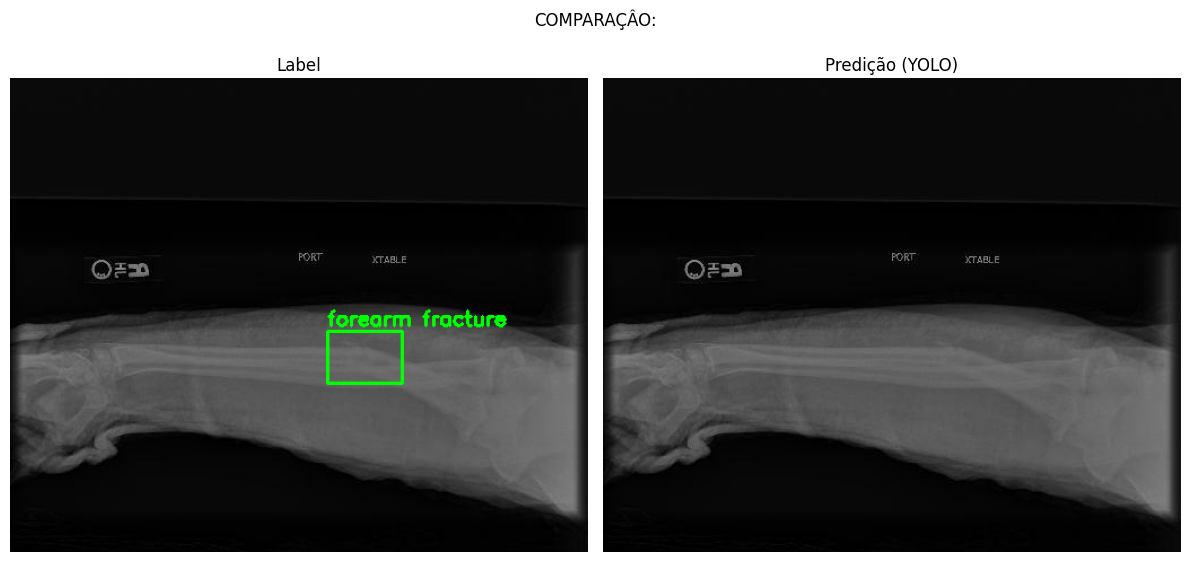

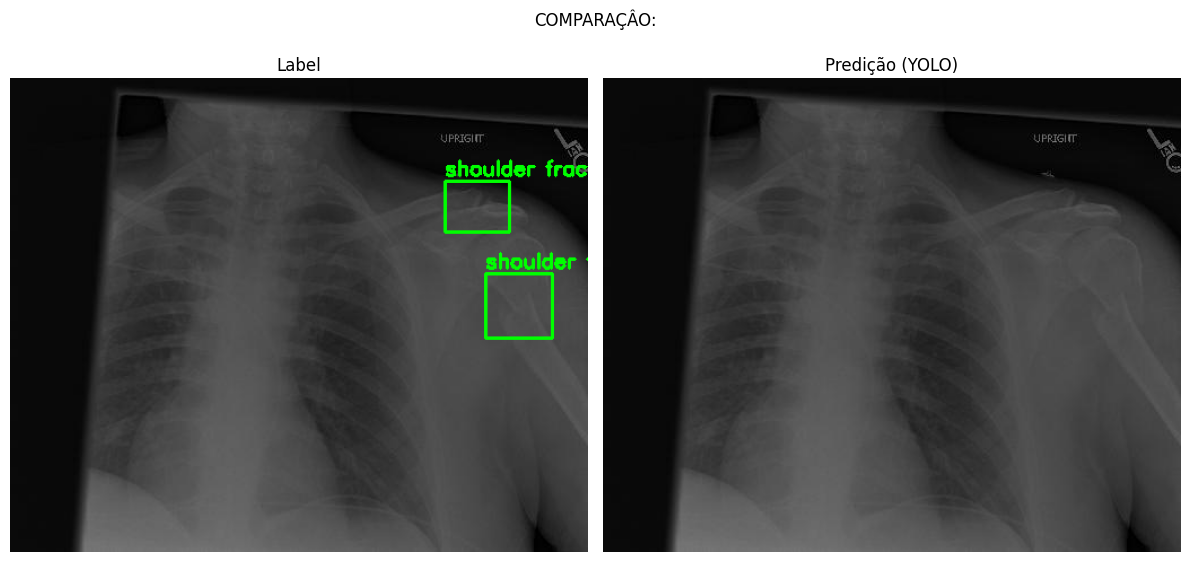

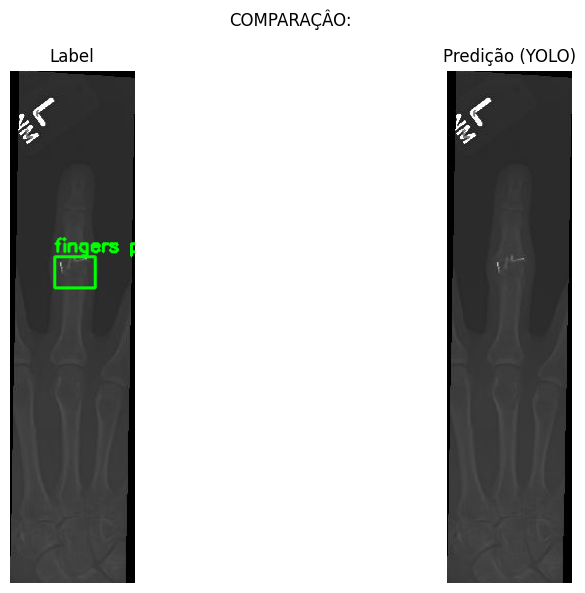

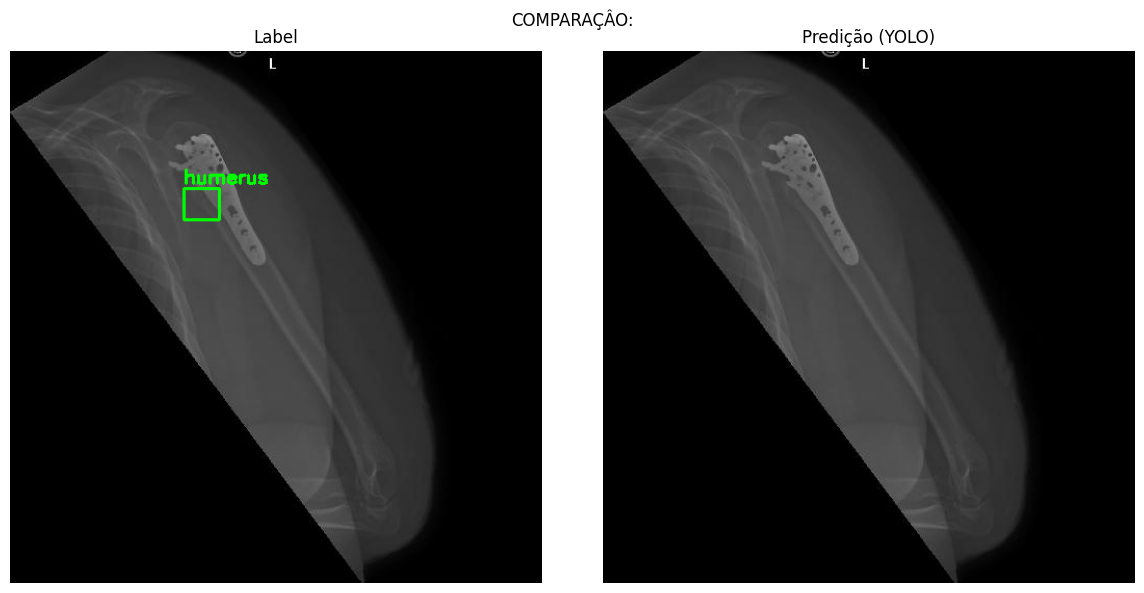

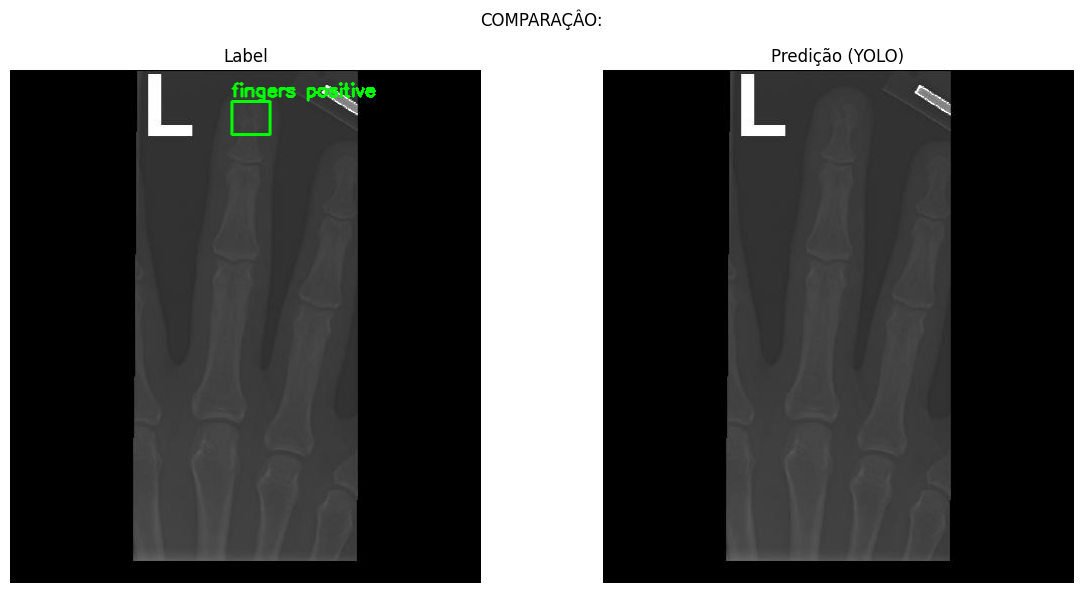

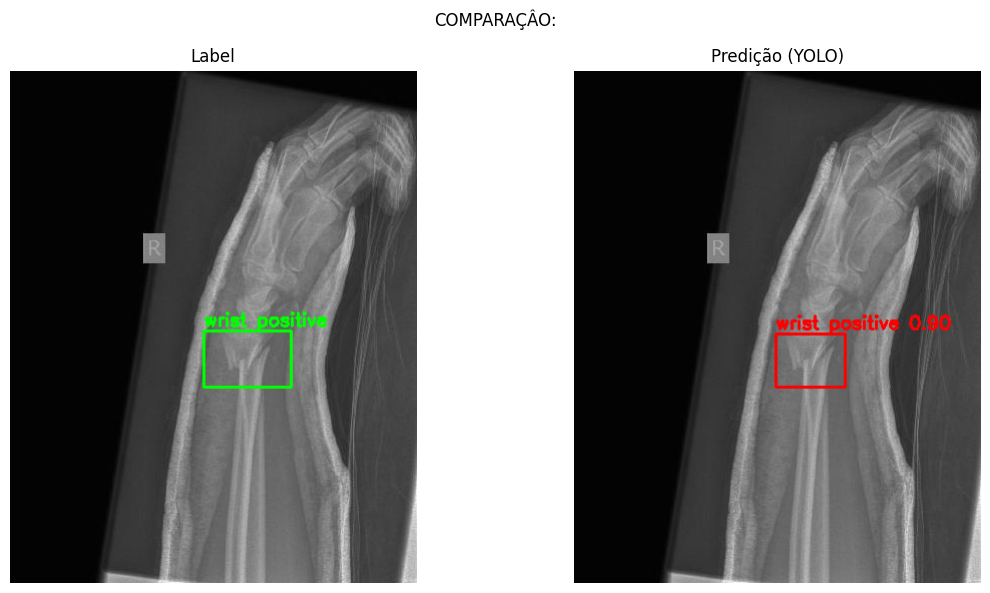

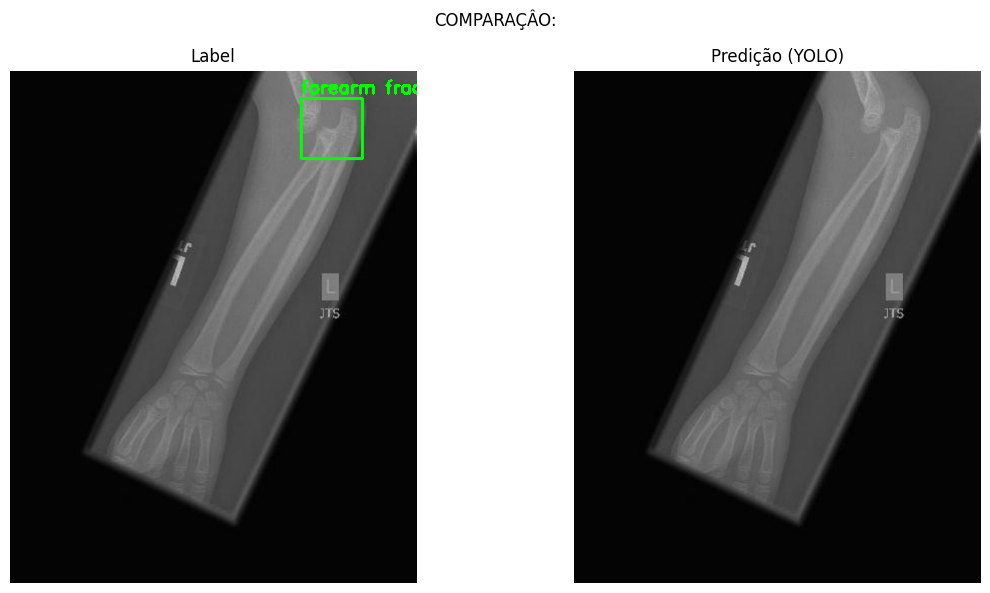

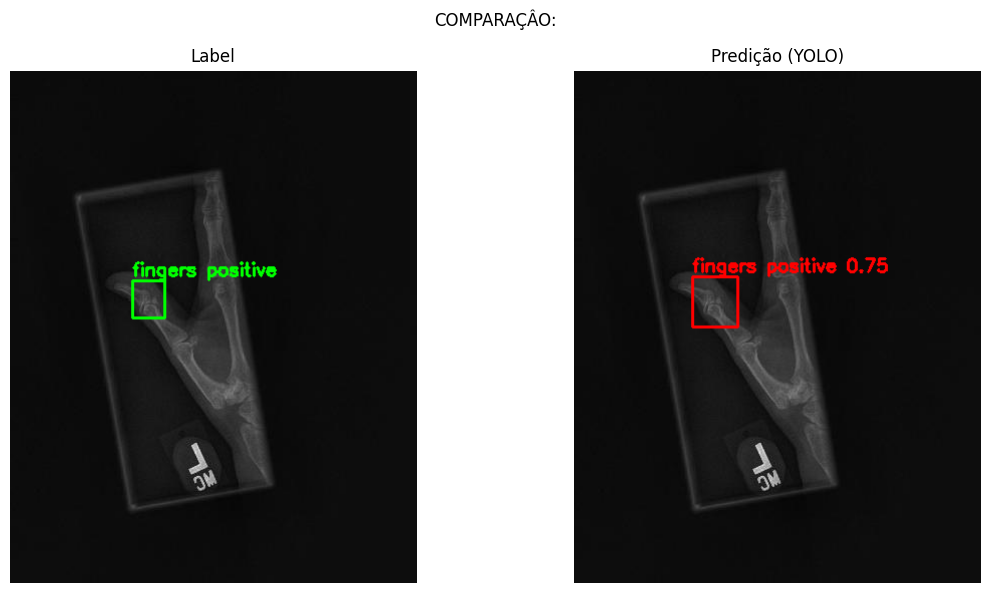

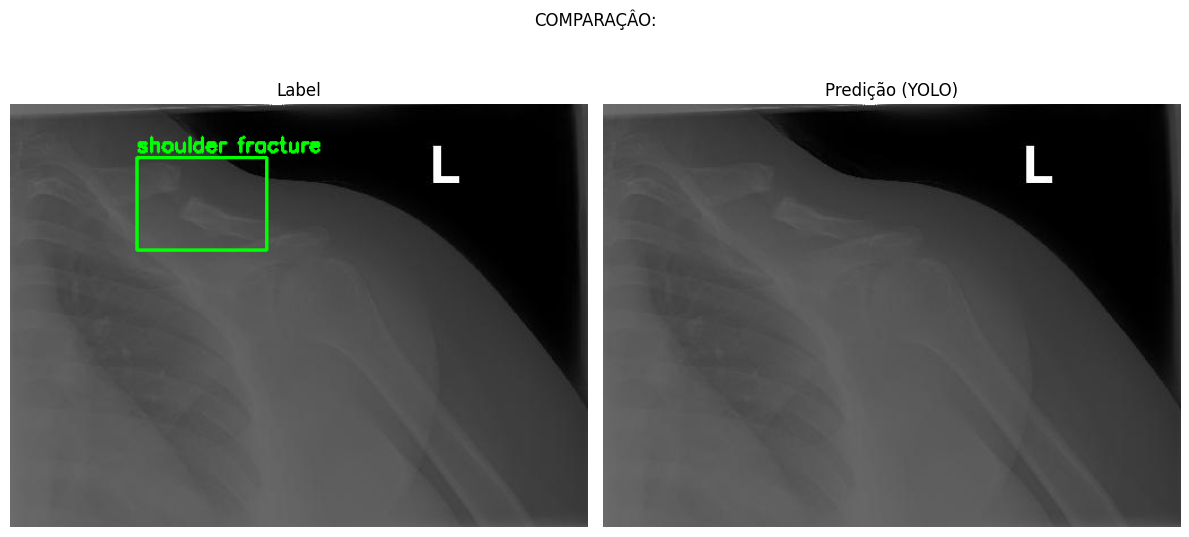

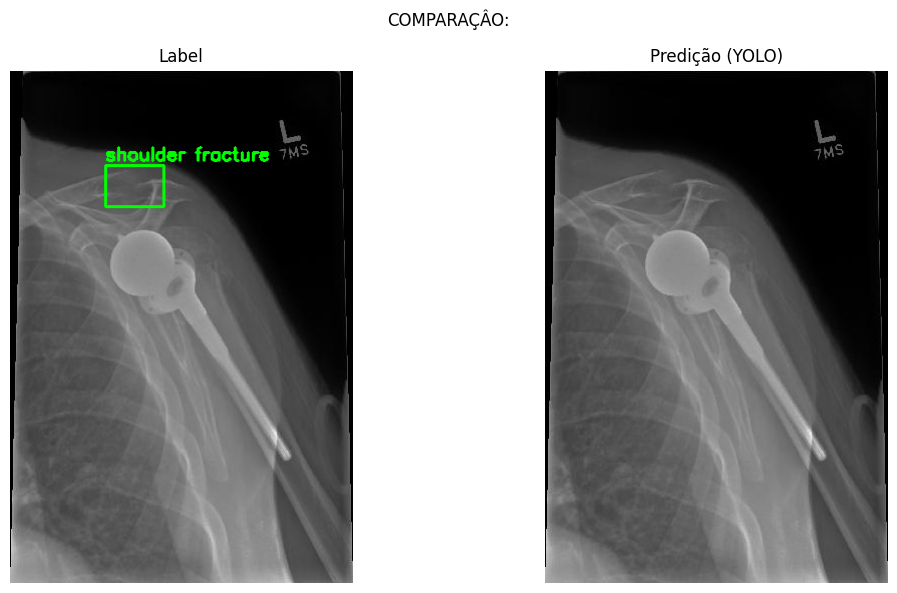

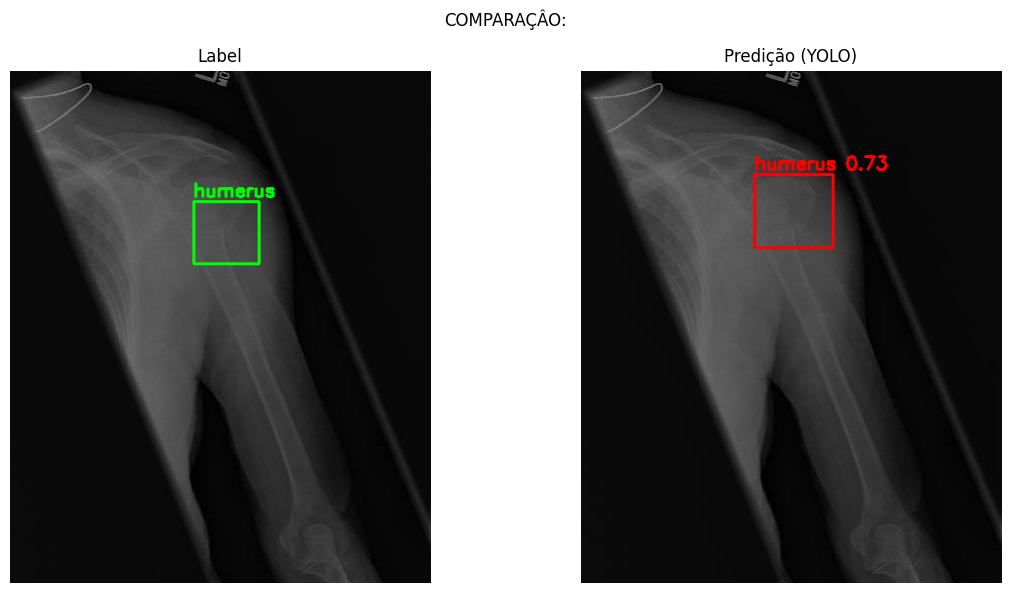

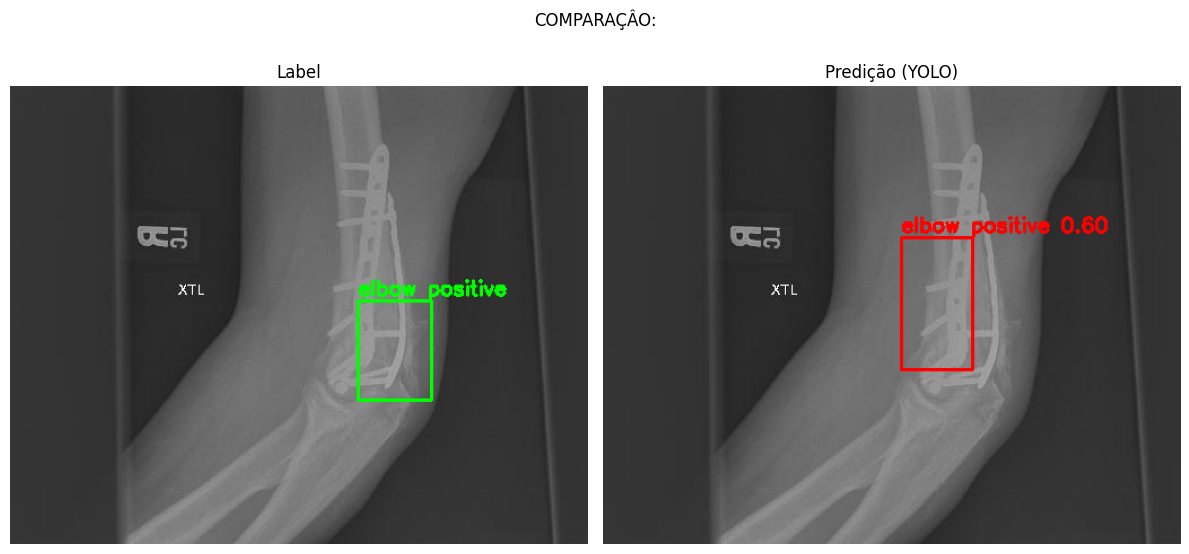

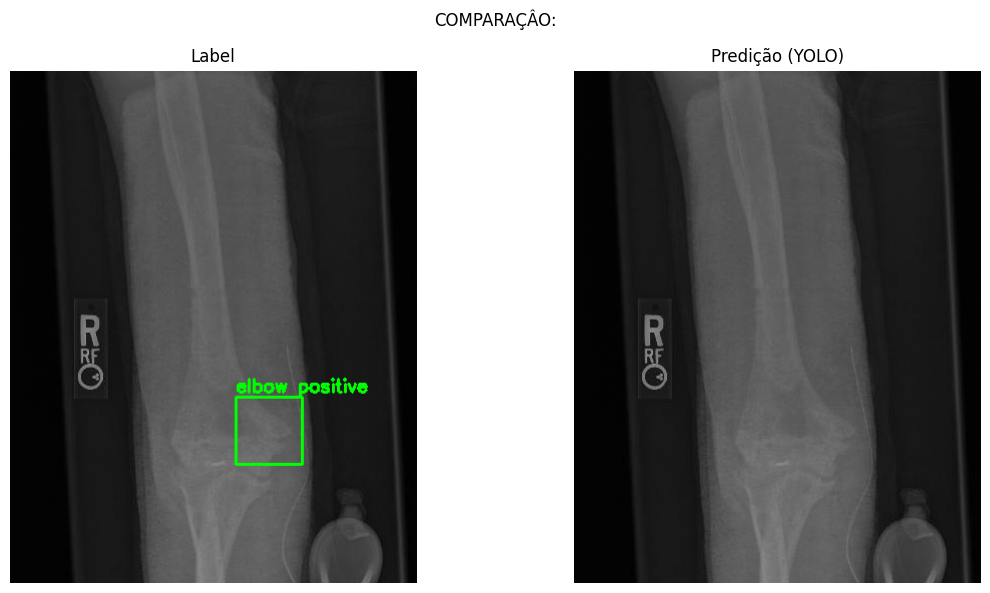

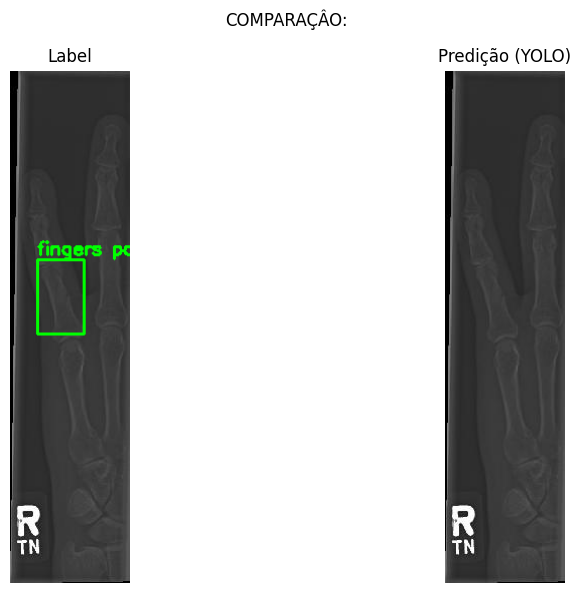

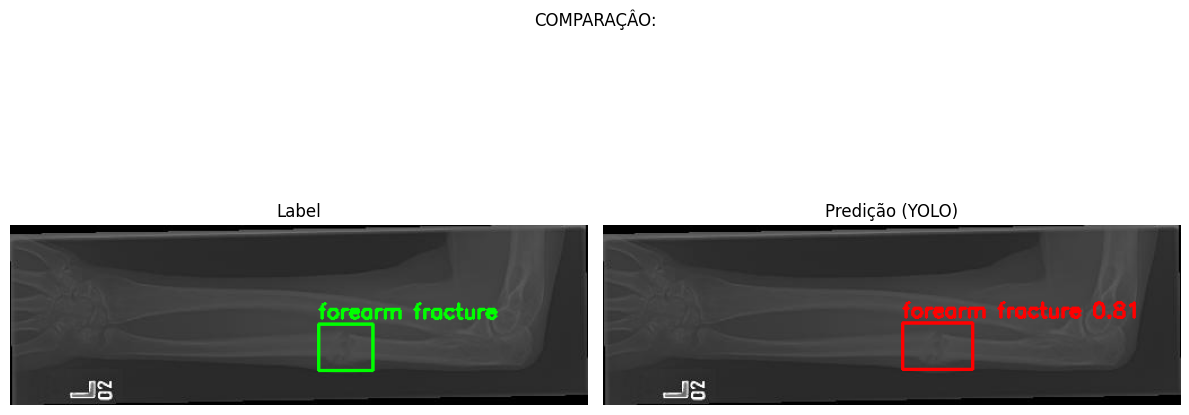

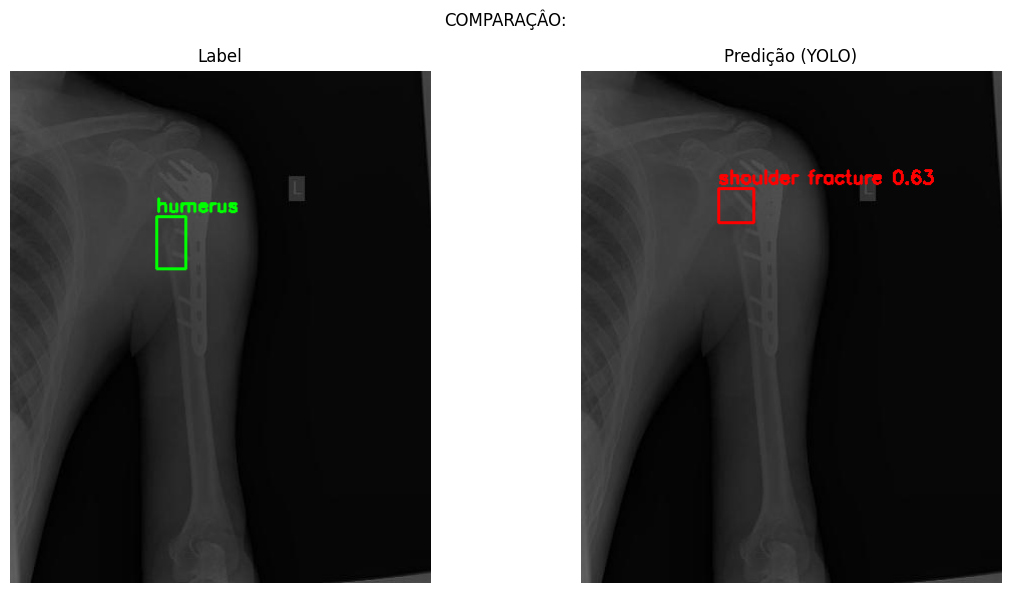

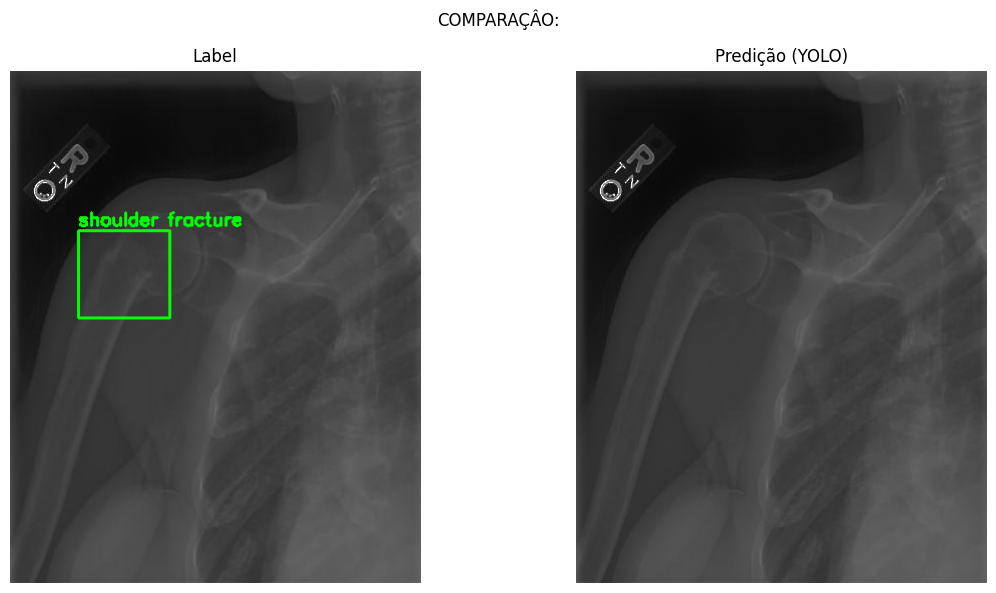

In [ ]:
#Melhor modelo
data_yaml = "/content/Bone_Fracture_Detect/BoneFractureYolo8/data.yaml"
visualizar_predicoes(model4, data_yaml, num_imagens=20, conf=0.25)

#Resultados e Discussão

Análise da matriz de confusão:

Mesmo sem as imagens de apenas background o modelo continua fazendo muitas previsões consideradas como “Falso Negativo” o que indica que essas imagens não estão influenciando o modelo a prever mais imagens como background.

A classe “fingers positive” tem a maior quantidade percentual de erros Falsos Positivos, o que indica que a região das mãos, com ossos de formatos complexos têm maiores confusões com fraturas reais. Além disso, as confusões entre as  classes também se dão nessa mesma região.

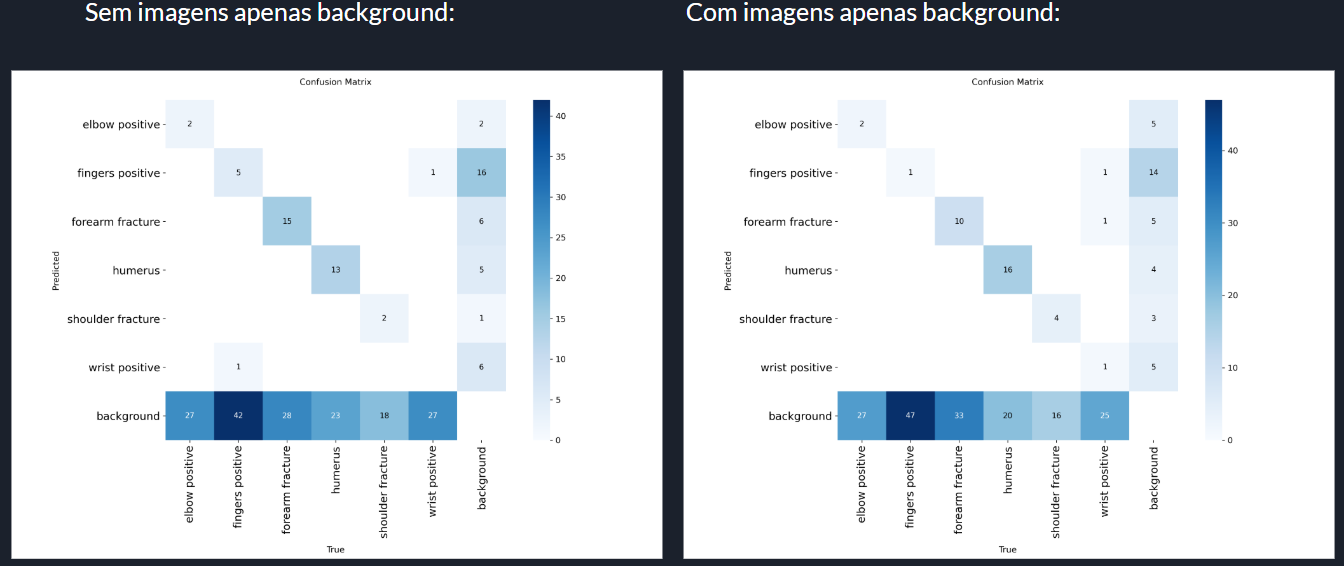

Nos dois casos os modelos apresentaram uma queda nas métricas de loss no treino que não foi correspondida pela queda de loss na validação, o que indica que o data augmentation não foi o suficiente para lidar com o overfitting dos modelo.

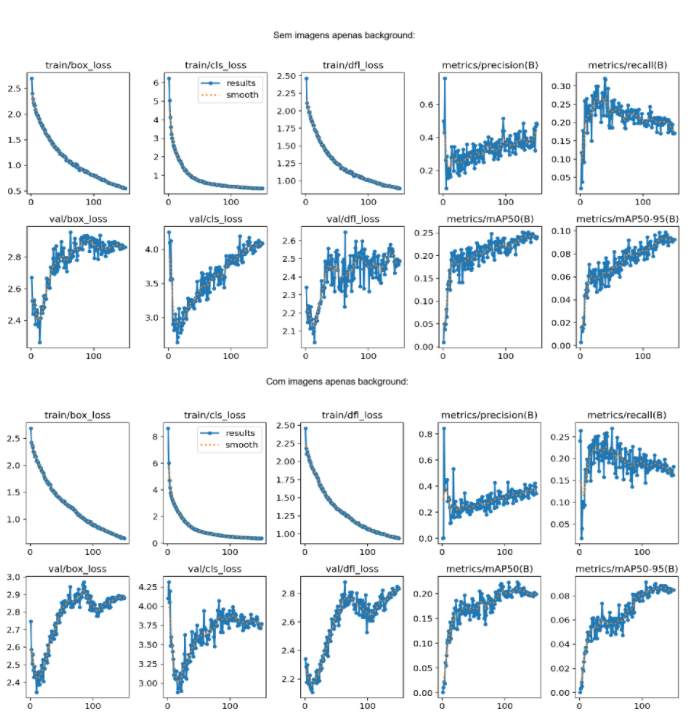
